In [1]:
import warnings
warnings.filterwarnings('ignore')

# Expalining Strategies for Expected Impacts

In this notebook, we present the the different data and plotting to validate our framework.
It is important to notice that:
- the time for finding the strategy is the sum of "time_create_execution_tree", "time_evaluate_cei_execution_tree", and "found_strategy_time";
- the time for explaining the strategy is the sum of "build_strategy_time", "time_explain_strategy", and "strategy_tree_time".

It is important to clarify that during aggregation, we compute and use the mean value. This ensures that the results reflect the average behavior across multiple instances rather than being influenced by outliers or extreme values.
Moreover, here multiple plot that have not been inserted into the article can be found.

In [2]:
from pony.orm import Database
import os
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path.cwd().resolve()
db_candidates = []
db_override = os.getenv("PACO_BENCHMARK_DB")
if db_override:
    db_candidates.append(Path(db_override))
db_candidates.extend([
    Path("validation/results/benchmarks_our.sqlite"),
    Path("benchmarks_our.sqlite"),
    ROOT / "validation/results/benchmarks_our.sqlite",
    ROOT / "benchmarks_our.sqlite",
    ROOT / "benchmarks.sqlite",
])
db_path = next((p for p in db_candidates if p.exists()), None)
if db_path is None:
    raise FileNotFoundError(f"No benchmarks DB found in candidates: {db_candidates}")

# database binding for our experiments
db = Database()
db.bind(provider='sqlite', filename=str(db_path), create_db=False)

# Get data from DB with dynamic schema
rows = db.execute("SELECT * FROM experiments")
columns = [row[1] for row in db.execute("PRAGMA table_info(experiments)")]
data = pd.DataFrame(rows, columns=columns)

# Normalize old/new schema names used by the notebook
rename_map = {}
if 'x' in data.columns and 'nested' not in data.columns:
    rename_map['x'] = 'nested'
if 'y' in data.columns and 'indep' not in data.columns:
    rename_map['y'] = 'indep'
if 'z' in data.columns and 'variant' not in data.columns:
    rename_map['z'] = 'variant'
if rename_map:
    data = data.rename(columns=rename_map)

print(f"Using DB: {db_path}")
print(f"Rows: {len(data)} | Cols: {len(data.columns)}")

Using DB: c:\Users\danie\Projects\GitHub\PACO\validation\results\benchmarks_our.sqlite
Rows: 3240 | Cols: 46


Table 1 - Row-level explainer metrics (sample)
Each row is one experiment instance. Structural factors are nested, indep, num_impacts, generation_mode.


,nested,indep,num_impacts,generation_mode,instance_id,process_choice_count,impact_mode_status,decision_mode_status,hybrid_mode_status,impact_mode_leaf_nodes,...,decision_mode_choices_total,decision_mode_choices_forced,decision_mode_choices_arbitrary,decision_mode_choices_impact_based,decision_mode_choices_decision_based,hybrid_mode_choices_total,hybrid_mode_choices_forced,hybrid_mode_choices_arbitrary,hybrid_mode_choices_impact_based,hybrid_mode_choices_decision_based
3232,3,1,10,bagging_remove_reverse,532,4,success,success,success,2,...,2,2,0,0,0,2,2,0,0,0
3238,3,1,10,bagging_remove_reverse,538,4,success,success,success,2,...,2,2,0,0,0,2,2,0,0,0
3191,3,1,10,bagging_remove_reverse_divide,491,0,not_attempted,not_attempted,not_attempted,0,...,0,0,0,0,0,0,0,0,0,0
3197,3,1,10,bagging_remove_reverse_divide,497,2,success,success,success,2,...,2,2,0,0,0,2,2,0,0,0
3203,3,1,10,bagging_remove_reverse_divide,503,1,success,success,success,1,...,1,1,0,0,0,1,1,0,0,0
3209,3,1,10,bagging_remove_reverse_divide,509,2,success,success,success,2,...,2,2,0,0,0,2,2,0,0,0
3215,3,1,10,bagging_remove_reverse_divide,515,4,success,success,success,2,...,2,2,0,0,0,2,2,0,0,0
3221,3,1,10,bagging_remove_reverse_divide,521,2,success,success,success,2,...,2,2,0,0,0,2,2,0,0,0
3227,3,1,10,bagging_remove_reverse_divide,527,2,success,success,success,2,...,2,2,0,0,0,2,2,0,0,0
3233,3,1,10,bagging_remove_reverse_divide,533,4,success,success,success,2,...,2,2,0,0,0,2,2,0,0,0


Table 2 - Joint structure distribution: nested x indep x num_impacts
This is the combined design space used to interpret time and explainability outcomes.


,nested,indep,choice_profile,num_impacts,experiments
0,1,1,"nested=1, indep=1",1,54
1,1,1,"nested=1, indep=1",2,54
2,1,1,"nested=1, indep=1",3,54
3,1,1,"nested=1, indep=1",4,54
4,1,1,"nested=1, indep=1",5,54
5,1,1,"nested=1, indep=1",6,54
6,1,1,"nested=1, indep=1",7,54
7,1,1,"nested=1, indep=1",8,54
8,1,1,"nested=1, indep=1",9,54
9,1,1,"nested=1, indep=1",10,54


Table 3 - Explainer outcome distribution by mode
This table reports how often each mode is success / failed / not_attempted.


,success,not_attempted
mode_outcome_column,,
impact_mode_status,2206,1034
decision_mode_status,2206,1034
hybrid_mode_status,2206,1034


Table 4 - Average explanation-tree leaf nodes by nested and indep


,nested,indep,impact_mode_leaf_nodes,decision_mode_leaf_nodes,hybrid_mode_leaf_nodes
0,1,1,0.463,0.463,0.463
1,1,2,0.994,0.994,0.994
2,1,3,1.426,1.426,1.426
3,2,1,0.809,0.809,0.809
4,2,2,1.128,1.128,1.128
5,3,1,1.376,1.376,1.376


Table 5 - Average choice typology by mode (successful experiments only)


,mode,successful_experiments,avg_choices_total,avg_choices_forced,avg_choices_arbitrary,avg_choices_impact_based,avg_choices_decision_based
0,impact_mode,2206,1.516,1.511,0.002,0.003,0.000
1,decision_mode,2206,1.516,1.511,0.002,0.000,0.003
2,hybrid_mode,2206,1.516,1.511,0.002,0.003,0.000


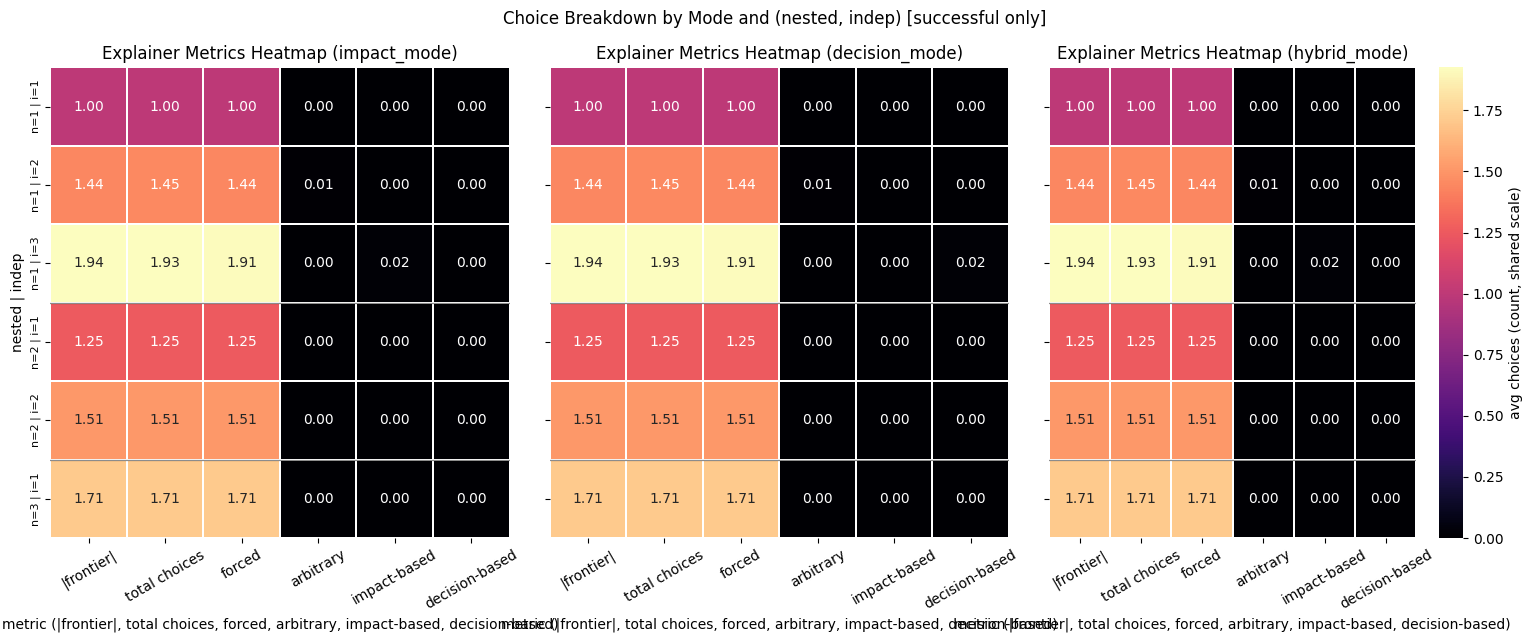

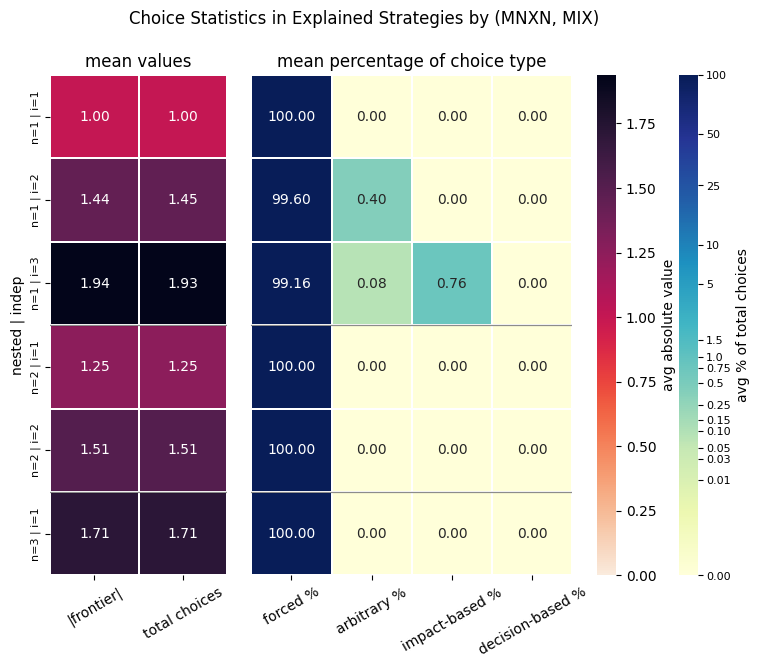

Table 6 - Explain time summary by mode (ms, successful experiments only)


,mode,successful_experiments,mean_ms,median_ms,p90_ms,p95_ms,min_ms,max_ms
0,decision_mode,2206,0.197,0.171,0.283,0.360,0.085,4.664
1,hybrid_mode,2206,0.114,0.098,0.153,0.197,0.053,6.252
2,impact_mode,2206,0.246,0.214,0.322,0.401,0.125,18.459


Table 7 - Paired time deltas on the same instance (ms)


,comparison,paired_experiments,mean_delta_ms,median_delta_ms,p90_abs_delta_ms
0,decision_mode - impact_mode,2206,-0.049,-0.039,0.087
1,hybrid_mode - impact_mode,2206,-0.131,-0.113,0.179
2,hybrid_mode - decision_mode,2206,-0.083,-0.072,0.136


Table 8 - Explain time by num_impacts and mode (ms, successful experiments only)


...

,nested,indep,choice_profile,num_impacts,mode,successful_experiments,median_ms
0,1,1,"nested=1, indep=1",1,decision_mode,14,0.199
1,1,1,"nested=1, indep=1",1,hybrid_mode,14,0.124
2,1,1,"nested=1, indep=1",1,impact_mode,14,0.244
3,1,1,"nested=1, indep=1",2,decision_mode,31,0.165
4,1,1,"nested=1, indep=1",2,hybrid_mode,31,0.105
...,...,...,...,...,...,...,...
115,2,1,"nested=2, indep=1",9,hybrid_mode,32,0.065
116,2,1,"nested=2, indep=1",9,impact_mode,32,0.162
117,2,1,"nested=2, indep=1",10,decision_mode,39,0.115
118,2,1,"nested=2, indep=1",10,hybrid_mode,39,0.064


Table 10 - Explainability outcomes by (nested, indep) and num_impacts


,nested,indep,choice_profile,num_impacts,experiments,impact_mode_success_rate,decision_mode_success_rate,hybrid_mode_success_rate,hybrid_impact_based_share,hybrid_decision_based_share
0,1,1,"nested=1, indep=1",1,54.0,0.2593,0.2593,0.2593,NaN,NaN
1,1,1,"nested=1, indep=1",2,54.0,0.5741,0.5741,0.5741,NaN,NaN
2,1,1,"nested=1, indep=1",3,54.0,0.4259,0.4259,0.4259,NaN,NaN
3,1,1,"nested=1, indep=1",4,54.0,0.4444,0.4444,0.4444,NaN,NaN
4,1,1,"nested=1, indep=1",5,54.0,0.4259,0.4259,0.4259,NaN,NaN
5,1,1,"nested=1, indep=1",6,54.0,0.5370,0.5370,0.5370,NaN,NaN
6,1,1,"nested=1, indep=1",7,54.0,0.4074,0.4074,0.4074,NaN,NaN
7,1,1,"nested=1, indep=1",8,54.0,0.4815,0.4815,0.4815,NaN,NaN
8,1,1,"nested=1, indep=1",9,54.0,0.5556,0.5556,0.5556,NaN,NaN
9,1,1,"nested=1, indep=1",10,54.0,0.5185,0.5185,0.5185,NaN,NaN


Table 11 - Mode success rates by (nested, indep) and num_impacts


,nested,indep,choice_profile,num_impacts,impact_mode_success_rate,decision_mode_success_rate,hybrid_mode_success_rate
0,1,1,"nested=1, indep=1",1,0.2593,0.2593,0.2593
1,1,1,"nested=1, indep=1",2,0.5741,0.5741,0.5741
2,1,1,"nested=1, indep=1",3,0.4259,0.4259,0.4259
3,1,1,"nested=1, indep=1",4,0.4444,0.4444,0.4444
4,1,1,"nested=1, indep=1",5,0.4259,0.4259,0.4259
5,1,1,"nested=1, indep=1",6,0.5370,0.5370,0.5370
6,1,1,"nested=1, indep=1",7,0.4074,0.4074,0.4074
7,1,1,"nested=1, indep=1",8,0.4815,0.4815,0.4815
8,1,1,"nested=1, indep=1",9,0.5556,0.5556,0.5556
9,1,1,"nested=1, indep=1",10,0.5185,0.5185,0.5185


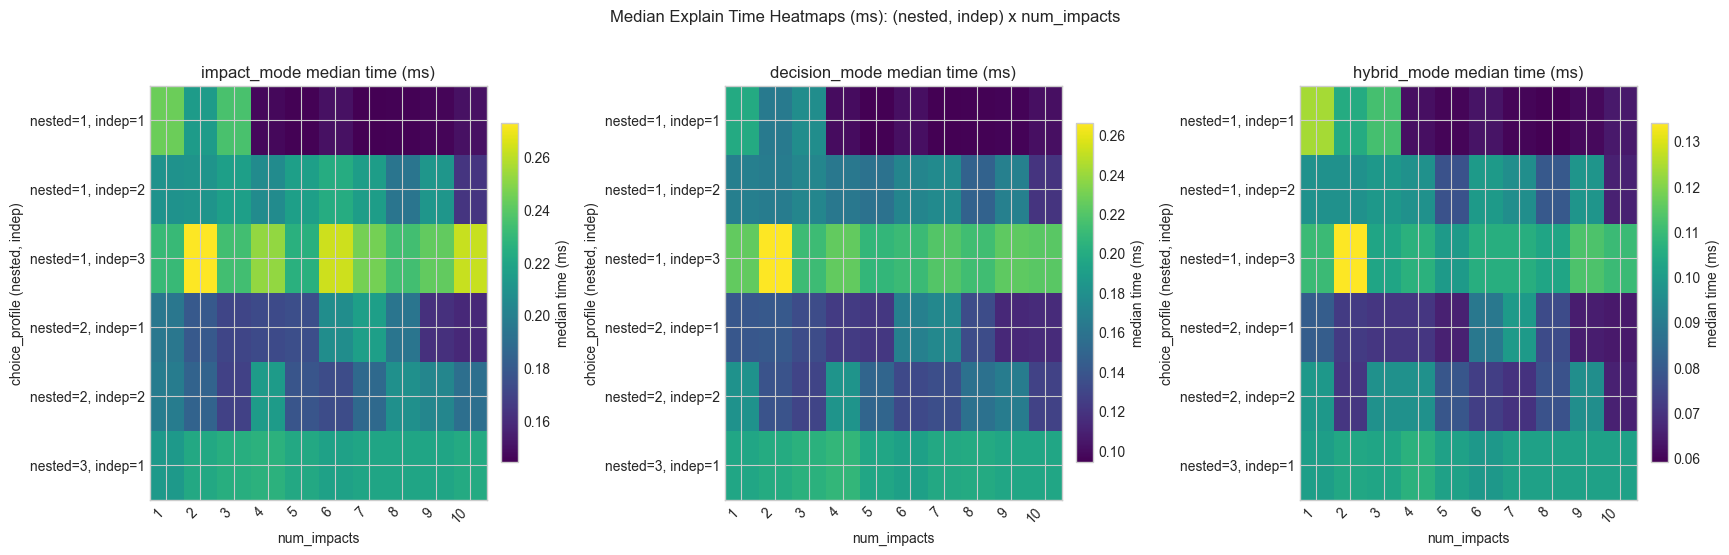

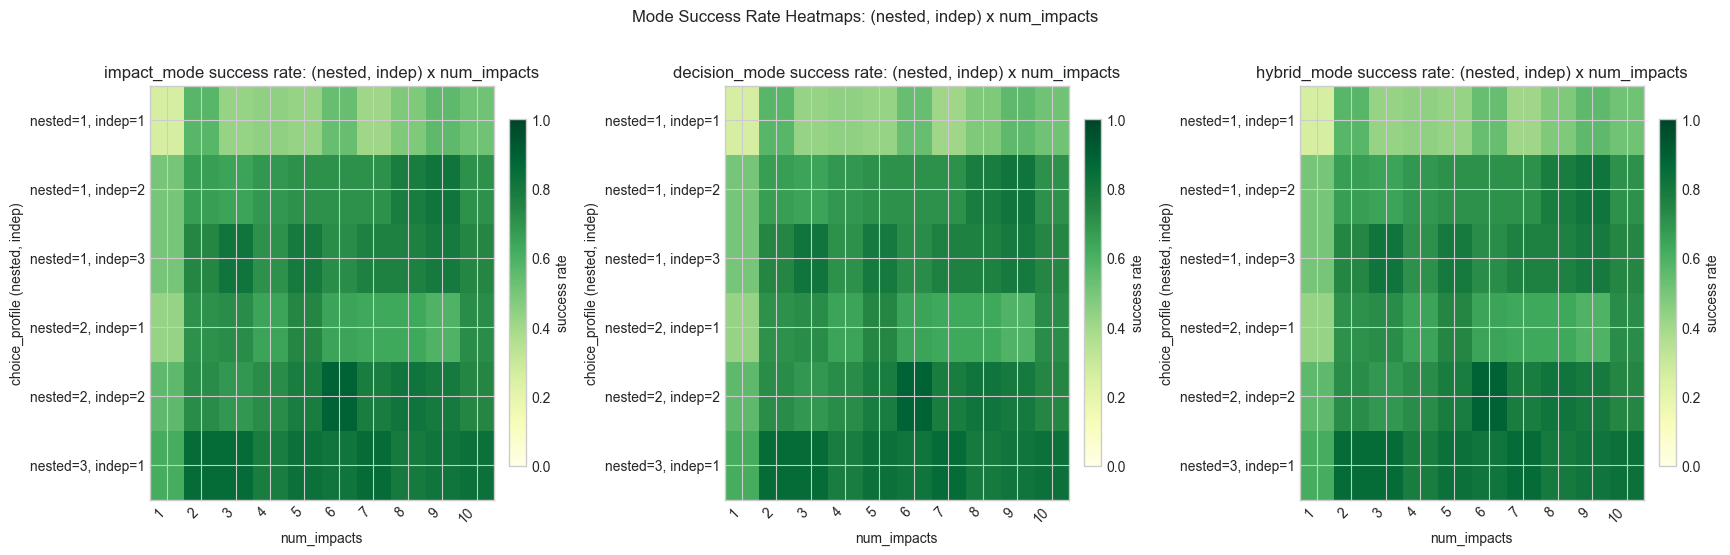

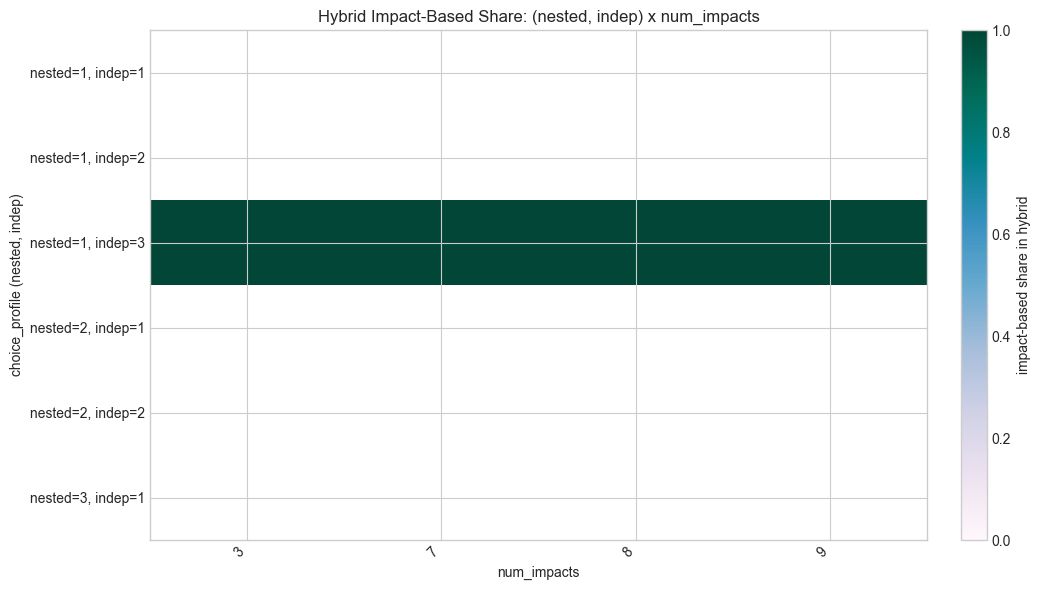

In [3]:
# Explainer metrics: execution modes + explanation-tree leaves + per-mode choice typology
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import gzip
import json
import re
from collections import Counter
from pathlib import Path

try:
    from src.experiments.etl.read import read_cpi_bundles as _read_cpi_bundles
except Exception:
    _read_cpi_bundles = None

status_cols = [
    'explain_strategy_impacts_based_status',
    'explain_strategy_decision_based_status',
    'explain_strategy_hybrid_status',
]

choice_cols = [
    'explainer_choices_impacts_based_total',
    'explainer_choices_impacts_based_forced',
    'explainer_choices_impacts_based_arbitrary',
    'explainer_choices_impacts_based_impacts',
    'explainer_choices_impacts_based_decision',
    'explainer_choices_decision_based_total',
    'explainer_choices_decision_based_forced',
    'explainer_choices_decision_based_arbitrary',
    'explainer_choices_decision_based_impacts',
    'explainer_choices_decision_based_decision',
    'explainer_choices_hybrid_total',
    'explainer_choices_hybrid_forced',
    'explainer_choices_hybrid_arbitrary',
    'explainer_choices_hybrid_impacts',
    'explainer_choices_hybrid_decision',
]

leaf_cols = [
    'explainer_leaves_impacts_based',
    'explainer_leaves_decision_based',
    'explainer_leaves_hybrid',
]

required = [c for c in (status_cols + choice_cols + leaf_cols) if c in data.columns]
if len(required) < len(status_cols):
    print('New explainer metrics are not available in this DB schema.')
else:
    # Normalize all count fields as integers.
    for c in choice_cols + leaf_cols:
        if c in data.columns:
            data[c] = pd.to_numeric(data[c], errors='coerce').fillna(0).astype(int)

    # Core structural factors
    data['nested'] = pd.to_numeric(data.get('nested', -1), errors='coerce').fillna(-1).astype(int)
    data['indep'] = pd.to_numeric(data.get('indep', -1), errors='coerce').fillna(-1).astype(int)
    data['num_impacts'] = pd.to_numeric(data.get('num_impacts', -1), errors='coerce').fillna(-1).astype(int)

    # ----- Process choice count from CPI bundle (auxiliary metric) -----
    bundle_cache = {}

    def resolve_cpi_dir():
        candidates = []
        root_value = globals().get('ROOT', None)
        if root_value is not None:
            candidates.append(Path(root_value) / 'validation/cpi-to-prism/CPIs')
        candidates.extend([
            Path('validation/cpi-to-prism/CPIs'),
            Path('../cpi-to-prism/CPIs'),
            Path('../../validation/cpi-to-prism/CPIs'),
        ])
        for c in candidates:
            if c.exists():
                return c
        return None

    cpi_dir = resolve_cpi_dir()

    def read_cpi_bundles_fallback(x, y):
        if cpi_dir is None:
            return []
        bundle_path = cpi_dir / f'cpi_bundle_x{x}_y{y}.cpis.gz'
        if not bundle_path.exists():
            return []
        with gzip.open(bundle_path, 'rt', encoding='utf-8') as f:
            return json.load(f)

    def get_bundle(x, y):
        key = (int(x), int(y))
        if key not in bundle_cache:
            bundle = []
            if _read_cpi_bundles is not None:
                try:
                    bundle = _read_cpi_bundles(x=key[0], y=key[1]) or []
                except Exception:
                    bundle = []
            if not bundle:
                bundle = read_cpi_bundles_fallback(x=key[0], y=key[1])
            bundle_cache[key] = bundle
        return bundle_cache[key]

    def count_node_types(node, counts):
        if isinstance(node, dict):
            node_type = node.get('type')
            if node_type is not None:
                counts[node_type] += 1
            for v in node.values():
                count_node_types(v, counts)
        elif isinstance(node, list):
            for item in node:
                count_node_types(item, counts)

    def process_choice_count(row):
        try:
            x = int(row['nested'])
            y = int(row['indep'])
            w = int(row['w'])
        except Exception:
            return None

        bundle = get_bundle(x, y)
        if w < 0 or w >= len(bundle):
            return None

        cpi_entry = bundle[w]
        model = {k: v for k, v in cpi_entry.items() if k != 'metadata'}
        counts = Counter()
        count_node_types(model, counts)
        return int(counts.get('choice', 0))

    data['process_choice_count'] = data.apply(process_choice_count, axis=1)
    data['choice_profile'] = data.apply(lambda r: f"nested={int(r['nested'])}, indep={int(r['indep'])}", axis=1)

    # ----- Paper-style presentation names -----
    rename_map = {
        'w': 'instance_id',
        'num_impacts': 'num_impacts',
        'process_choice_count': 'process_choice_count',
        'choice_profile': 'choice_profile',
        'explain_strategy_impacts_based_status': 'impact_mode_status',
        'explain_strategy_decision_based_status': 'decision_mode_status',
        'explain_strategy_hybrid_status': 'hybrid_mode_status',
        'explainer_leaves_impacts_based': 'impact_mode_leaf_nodes',
        'explainer_leaves_decision_based': 'decision_mode_leaf_nodes',
        'explainer_leaves_hybrid': 'hybrid_mode_leaf_nodes',
    }

    mode_label = {
        'impacts_based': 'impact_mode',
        'decision_based': 'decision_mode',
        'hybrid': 'hybrid_mode',
    }
    metric_label = {
        'total': 'choices_total',
        'forced': 'choices_forced',
        'arbitrary': 'choices_arbitrary',
        'impacts': 'choices_impact_based',
        'decision': 'choices_decision_based',
    }

    for col in choice_cols:
        m = re.match(r'^explainer_choices_(impacts_based|decision_based|hybrid)_(total|forced|arbitrary|impacts|decision)$', col)
        if m:
            mode, metric = m.groups()
            rename_map[col] = f"{mode_label[mode]}_{metric_label[metric]}"

    def present(df: pd.DataFrame) -> pd.DataFrame:
        return df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    # ===== Table 1: row-level metrics =====
    table_1_cols = [c for c in [
        'nested', 'indep', 'num_impacts', 'generation_mode', 'w', 'process_choice_count',
        'explain_strategy_impacts_based_status',
        'explain_strategy_decision_based_status',
        'explain_strategy_hybrid_status',
        'explainer_leaves_impacts_based',
        'explainer_leaves_decision_based',
        'explainer_leaves_hybrid',
        'choice_profile',
    ] + choice_cols if c in data.columns]

    table_1 = present(data[table_1_cols].copy())
    table_1 = table_1.sort_values(['nested', 'indep', 'num_impacts', 'generation_mode', 'instance_id'])

    print('Table 1 - Row-level explainer metrics (sample)')
    print('Each row is one experiment instance. Structural factors are nested, indep, num_impacts, generation_mode.')
    display(table_1.tail(20))

    # ===== Table 2: joint structure distribution (nested x indep x num_impacts) =====
    process_impact_dist = (
        data.groupby(['nested', 'indep', 'choice_profile', 'num_impacts'])
            .size()
            .reset_index(name='experiments')
            .sort_values(['nested', 'indep', 'num_impacts'])
    )

    print('Table 2 - Joint structure distribution: nested x indep x num_impacts')
    print('This is the combined design space used to interpret time and explainability outcomes.')
    display(present(process_impact_dist).head(120))

    # ===== Table 3: mode outcome distribution =====
    status_distribution = []
    for col in status_cols:
        if col in data.columns:
            status_distribution.append(data[col].fillna('NaN').value_counts().rename(col))

    if status_distribution:
        table_3 = pd.concat(status_distribution, axis=1).fillna(0).astype(int).T
        table_3.index = table_3.index.map({
            'explain_strategy_impacts_based_status': 'impact_mode_status',
            'explain_strategy_decision_based_status': 'decision_mode_status',
            'explain_strategy_hybrid_status': 'hybrid_mode_status',
        })
        table_3.index.name = 'mode_outcome_column'

        print('Table 3 - Explainer outcome distribution by mode')
        print('This table reports how often each mode is success / failed / not_attempted.')
        display(table_3)

    # ===== Table 4: average leaf nodes by nested and indep =====
    table_4 = (
        data.groupby(['nested', 'indep'])[leaf_cols]
            .mean()
            .round(3)
            .reset_index()
            .sort_values(['nested', 'indep'])
    )

    print('Table 4 - Average explanation-tree leaf nodes by nested and indep')
    display(present(table_4))

    # ===== Table 5: average choice typology per mode (successful runs only) =====
    rows = []
    for mode_key in ['impacts_based', 'decision_based', 'hybrid']:
        status_col = f'explain_strategy_{mode_key}_status'
        if status_col not in data.columns:
            continue

        successful = data[status_col] == 'success'
        row = {
            'mode': mode_label[mode_key],
            'successful_experiments': int(successful.sum()),
        }

        for metric in ['total', 'forced', 'arbitrary', 'impacts', 'decision']:
            col = f'explainer_choices_{mode_key}_{metric}'
            out_col = metric_label[metric]
            if col in data.columns and successful.any():
                row[f'avg_{out_col}'] = round(float(data.loc[successful, col].mean()), 3)
            else:
                row[f'avg_{out_col}'] = 0.0

        rows.append(row)

    table_5 = pd.DataFrame(rows)
    print('Table 5 - Average choice typology by mode (successful experiments only)')
    display(table_5)

    # ===== Mode-Metrics Charts (successful runs only) =====
    mode_specs = [
        ('impacts_based', 'impact_mode'),
        ('decision_based', 'decision_mode'),
        ('hybrid', 'hybrid_mode'),
    ]
    choice_mode_specs = [('hybrid', 'hybrid_mode')]

    # Single mode-metrics heatmap (includes leaf_nodes + choice metrics)
    # Chart M1: multicolor heatmaps of explainer metrics by mode and joint factors
    # Single mode-metrics heatmap (absolute values)
    choice_joint_rows_abs = []
    for mode_key, mode_name in mode_specs:
        status_col = f'explain_strategy_{mode_key}_status'
        source_cols_abs = {
            'leaf_nodes': f'explainer_leaves_{mode_key}',
            'total': f'explainer_choices_{mode_key}_total',
            'forced': f'explainer_choices_{mode_key}_forced',
            'arbitrary': f'explainer_choices_{mode_key}_arbitrary',
            'impact_based': f'explainer_choices_{mode_key}_impacts',
            'decision_based': f'explainer_choices_{mode_key}_decision',
        }
        if status_col not in data.columns or not all(c in data.columns for c in source_cols_abs.values()):
            continue

        successful_rows_abs = data.loc[
            data[status_col] == 'success',
            ['nested', 'indep'] + list(source_cols_abs.values())
        ].copy()
        if successful_rows_abs.empty:
            continue

        grouped_abs = (
            successful_rows_abs
            .groupby(['nested', 'indep'])[list(source_cols_abs.values())]
            .mean()
            .reset_index()
        )
        grouped_abs = grouped_abs.rename(columns={v: k for k, v in source_cols_abs.items()})
        grouped_abs['mode'] = mode_name
        grouped_abs['joint_key'] = (
            'n=' + grouped_abs['nested'].astype(int).astype(str)
            + ' | i=' + grouped_abs['indep'].astype(int).astype(str)
        )
        choice_joint_rows_abs.append(grouped_abs)

    choice_summary_joint_abs = pd.concat(choice_joint_rows_abs, ignore_index=True) if choice_joint_rows_abs else pd.DataFrame()
    if not choice_summary_joint_abs.empty:
        joint_meta_abs = (
            choice_summary_joint_abs[['nested', 'indep', 'joint_key']]
            .drop_duplicates()
            .sort_values(['nested', 'indep'])
            .reset_index(drop=True)
        )
        joint_order_abs = joint_meta_abs['joint_key'].tolist()

        mode_order = [mode_name for _, mode_name in mode_specs]
        metric_cols_abs = ['leaf_nodes', 'total', 'forced', 'arbitrary', 'impact_based', 'decision_based']
        metric_display_labels_abs = {
            'leaf_nodes': '|frontier|',
            'total': 'total choices',
            'forced': 'forced',
            'arbitrary': 'arbitrary',
            'impact_based': 'impact-based',
            'decision_based': 'decision-based',
        }

        choice_vals_abs = choice_summary_joint_abs[metric_cols_abs].to_numpy().flatten()
        choice_vals_abs = [v for v in choice_vals_abs if pd.notna(v)]
        choice_vmax_abs = np.percentile(choice_vals_abs, 95) if choice_vals_abs else 1.0
        choice_vmax_abs = max(float(choice_vmax_abs), 1e-9)
        choice_annot_abs = len(joint_order_abs) <= 20

        fig_height_abs = min(18, max(6.5, 0.35 * len(joint_order_abs)))
        fig, axes = plt.subplots(1, len(mode_order), figsize=(5.2 * len(mode_order), fig_height_abs), sharey=True)
        if len(mode_order) == 1:
            axes = [axes]

        boundaries_abs = []
        for i in range(1, len(joint_meta_abs)):
            if int(joint_meta_abs.loc[i, 'nested']) != int(joint_meta_abs.loc[i - 1, 'nested']):
                boundaries_abs.append(i)

        for idx, (ax, mode_name) in enumerate(zip(axes, mode_order)):
            mode_df_abs = (
                choice_summary_joint_abs[choice_summary_joint_abs['mode'] == mode_name]
                .set_index('joint_key')
                .reindex(joint_order_abs)
            )
            heat_mode_abs = mode_df_abs[metric_cols_abs].rename(columns=metric_display_labels_abs)
            sns.heatmap(
                heat_mode_abs,
                cmap='magma',
                vmin=0,
                vmax=choice_vmax_abs,
                annot=choice_annot_abs,
                fmt='.2f',
                linewidths=0.30,
                linecolor='white',
                cbar=(idx == len(mode_order) - 1),
                cbar_kws={'label': 'avg choices (count, shared scale)'},
                ax=ax,
            )
            for b in boundaries_abs:
                ax.axhline(b, color='black', linewidth=0.9, alpha=0.45)
            ax.set_title(f'Explainer Metrics Heatmap ({mode_name})')
            ax.set_xlabel('metric (|frontier|, total choices, forced, arbitrary, impact-based, decision-based)')
            if idx == 0:
                ax.set_ylabel('nested | indep')
            else:
                ax.set_ylabel('')
            ax.tick_params(axis='x', rotation=30)
            ax.tick_params(axis='y', labelsize=8 if len(joint_order_abs) <= 40 else 6)

        plt.suptitle('Choice Breakdown by Mode and (nested, indep) [successful only]')
        plt.tight_layout()
        plt.show()

    choice_joint_rows = []
    for mode_key, mode_name in choice_mode_specs:
        status_col = f'explain_strategy_{mode_key}_status'
        source_cols = {
            'leaf_nodes': f'explainer_leaves_{mode_key}',
            'total': f'explainer_choices_{mode_key}_total',
            'forced': f'explainer_choices_{mode_key}_forced',
            'arbitrary': f'explainer_choices_{mode_key}_arbitrary',
            'impact_based': f'explainer_choices_{mode_key}_impacts',
            'decision_based': f'explainer_choices_{mode_key}_decision',
        }
        if status_col not in data.columns or not all(c in data.columns for c in source_cols.values()):
            continue

        successful_rows = data.loc[
            data[status_col] == 'success',
            ['nested', 'indep'] + list(source_cols.values())
        ].copy()
        if successful_rows.empty:
            continue

        total_col = source_cols['total']
        for share_metric in ['forced', 'arbitrary', 'impact_based', 'decision_based']:
            metric_col = source_cols[share_metric]
            successful_rows[metric_col] = np.where(
                successful_rows[total_col] > 0,
                100.0 * successful_rows[metric_col] / successful_rows[total_col],
                0.0,
            )

        grouped = (
            successful_rows
            .groupby(['nested', 'indep'])[list(source_cols.values())]
            .mean()
            .reset_index()
        )
        grouped = grouped.rename(columns={v: k for k, v in source_cols.items()})
        grouped['mode'] = mode_name
        grouped['joint_key'] = (
            'n=' + grouped['nested'].astype(int).astype(str)
            + ' | i=' + grouped['indep'].astype(int).astype(str)
        )
        choice_joint_rows.append(grouped)

    choice_summary_joint = pd.concat(choice_joint_rows, ignore_index=True) if choice_joint_rows else pd.DataFrame()
    if not choice_summary_joint.empty:
        joint_meta = (
            choice_summary_joint[['nested', 'indep', 'joint_key']]
            .drop_duplicates()
            .sort_values(['nested', 'indep'])
            .reset_index(drop=True)
        )
        joint_order = joint_meta['joint_key'].tolist()

        mode_order = [mode_name for _, mode_name in choice_mode_specs]
        abs_metric_cols = ['leaf_nodes', 'total']
        pct_metric_cols = ['forced', 'arbitrary', 'impact_based', 'decision_based']
        metric_display_labels = {
            'leaf_nodes': '|frontier|',
            'total': 'total choices',
            'forced': 'forced %',
            'arbitrary': 'arbitrary %',
            'impact_based': 'impact-based %',
            'decision_based': 'decision-based %',
        }

        abs_vals = choice_summary_joint[abs_metric_cols].to_numpy().flatten()
        abs_vals = [v for v in abs_vals if pd.notna(v)]
        abs_vmax = np.percentile(abs_vals, 95) if abs_vals else 1.0
        abs_vmax = max(float(abs_vmax), 1e-9)
        pct_vmin, pct_vmax = 0.0, 100.0
        pct_norm = mcolors.PowerNorm(gamma=0.18, vmin=pct_vmin, vmax=pct_vmax)
        choice_annot = len(joint_order) <= 20

        fig_height = min(18, max(6.5, 0.35 * len(joint_order)))
        width_ratios = []
        for _ in mode_order:
            width_ratios.extend([2.2, 4.0])
        width_ratios.extend([0.24, 0.18, 0.24])

        fig_width = sum(width_ratios) + 1.5
        fig = plt.figure(figsize=(fig_width, fig_height))
        gs = fig.add_gridspec(
            1,
            len(mode_order) * 2 + 3,
            width_ratios=width_ratios,
            wspace=0.22,
        )

        boundaries = []
        for i in range(1, len(joint_meta)):
            if int(joint_meta.loc[i, 'nested']) != int(joint_meta.loc[i - 1, 'nested']):
                boundaries.append(i)

        shared_abs_ax = None
        cbar_abs_ax = fig.add_subplot(gs[0, -3])
        cbar_pct_ax = fig.add_subplot(gs[0, -1])

        for idx, mode_name in enumerate(mode_order):
            abs_ax = fig.add_subplot(gs[0, 2 * idx], sharey=shared_abs_ax)
            pct_ax = fig.add_subplot(gs[0, 2 * idx + 1], sharey=abs_ax)
            if shared_abs_ax is None:
                shared_abs_ax = abs_ax

            mode_df = (
                choice_summary_joint[choice_summary_joint['mode'] == mode_name]
                .set_index('joint_key')
                .reindex(joint_order)
            )
            heat_mode_raw = mode_df[abs_metric_cols + pct_metric_cols].rename(columns=metric_display_labels)
            heat_abs = heat_mode_raw[[metric_display_labels[c] for c in abs_metric_cols]]
            heat_pct = heat_mode_raw[[metric_display_labels[c] for c in pct_metric_cols]]
            heat_pct_for_colors = heat_pct.clip(upper=pct_vmax)

            sns.heatmap(
                heat_abs,
                cmap='rocket_r',
                vmin=0,
                vmax=abs_vmax,
                annot=heat_abs if choice_annot else False,
                fmt='.2f',
                linewidths=0.30,
                linecolor='white',
                cbar=(idx == 0),
                cbar_ax=cbar_abs_ax if idx == 0 else None,
                cbar_kws={'label': 'avg absolute value'},
                ax=abs_ax,
            )
            sns.heatmap(
                heat_pct_for_colors,
                cmap='YlGnBu',
                norm=pct_norm,
                annot=heat_pct if choice_annot else False,
                fmt='.2f',
                linewidths=0.30,
                linecolor='white',
                cbar=(idx == 0),
                cbar_ax=cbar_pct_ax if idx == 0 else None,
                cbar_kws={'label': 'avg % of total choices', 'ticks': [0.00, 0.01, 0.03, 0.05, 0.10, 0.15, 0.25, 0.5, 0.75, 1.0, 1.5, 5, 10, 25, 50, 100]},
                ax=pct_ax,
            )
            if idx == 0:
                pct_cbar = pct_ax.collections[0].colorbar
                pct_ticks = [0.00, 0.01, 0.03, 0.05, 0.10, 0.15, 0.25, 0.5, 0.75, 1.0, 1.5, 5, 10, 25, 50, 100]
                pct_ticklabels = ['0.00', '0.01', '0.03', '0.05', '0.10', '0.15', '0.25', '0.5', '0.75', '1.0', '1.5', '5', '10', '25', '50', '100']
                pct_cbar.set_ticks(pct_ticks)
                pct_cbar.set_ticklabels(pct_ticklabels)
                pct_cbar.ax.tick_params(labelsize=8, pad=2)

            for b in boundaries:
                abs_ax.axhline(b, color='black', linewidth=0.9, alpha=0.45)
                pct_ax.axhline(b, color='black', linewidth=0.9, alpha=0.45)

            abs_ax.set_title('mean values')
            pct_ax.set_title('mean percentage of choice type')
            abs_ax.set_xlabel('')
            pct_ax.set_xlabel('')
            abs_ax.tick_params(axis='x', rotation=30)
            pct_ax.tick_params(axis='x', rotation=30)

            if idx == 0:
                abs_ax.set_ylabel('nested | indep')
                abs_ax.tick_params(axis='y', labelsize=8 if len(joint_order) <= 40 else 6)
            else:
                abs_ax.set_ylabel('')
                abs_ax.tick_params(axis='y', left=False, labelleft=False)

            pct_ax.set_ylabel('')
            pct_ax.tick_params(axis='y', left=False, labelleft=False)

        plt.suptitle('Choice Statistics in Explained Strategies by (MNXN, MIX)')
        plt.tight_layout(rect=[0, 0, 0.97, 0.97])
        plt.show()

    # ===== Charts (Joint Factors Only) =====
    plt.style.use('seaborn-v0_8-whitegrid')

    # Joint Distribution Heatmap removed on request.

    # ===== Timing Comparison Across Explainer Modes =====
    time_specs = [
        ('impact_mode', 'time_explain_strategy_impacts_based', 'explain_strategy_impacts_based_status'),
        ('decision_mode', 'time_explain_strategy_decision_based', 'explain_strategy_decision_based_status'),
        ('hybrid_mode', 'time_explain_strategy_hybrid', 'explain_strategy_hybrid_status'),
    ]

    for _, time_col, _ in time_specs:
        if time_col in data.columns:
            data[time_col] = pd.to_numeric(data[time_col], errors='coerce').fillna(0.0)

    time_frames = []
    for mode_name, time_col, status_col in time_specs:
        if time_col not in data.columns or status_col not in data.columns:
            continue

        successful = data[status_col] == 'success'
        select_cols = ['nested', 'indep', 'choice_profile', 'num_impacts', 'w', time_col]
        tmp = data.loc[successful, [c for c in select_cols if c in data.columns]].copy()
        tmp = tmp.rename(columns={'w': 'instance_id', time_col: 'time_ms'})
        tmp['mode'] = mode_name
        time_frames.append(tmp)

    time_long = pd.concat(time_frames, ignore_index=True) if time_frames else pd.DataFrame(columns=['nested', 'indep', 'choice_profile', 'num_impacts', 'instance_id', 'time_ms', 'mode'])

    # Table 6
    if not time_long.empty:
        table_6 = (
            time_long.groupby('mode')['time_ms']
                .agg(
                    successful_experiments='count',
                    mean_ms='mean',
                    median_ms='median',
                    p90_ms=lambda s: s.quantile(0.90),
                    p95_ms=lambda s: s.quantile(0.95),
                    min_ms='min',
                    max_ms='max',
                )
                .round(3)
                .reset_index()
        )
    else:
        table_6 = pd.DataFrame(columns=['mode', 'successful_experiments', 'mean_ms', 'median_ms', 'p90_ms', 'p95_ms', 'min_ms', 'max_ms'])

    print('Table 6 - Explain time summary by mode (ms, successful experiments only)')
    display(table_6)

    # Table 7
    paired_defs = [
        ('decision_mode - impact_mode', 'time_explain_strategy_decision_based', 'time_explain_strategy_impacts_based', 'explain_strategy_decision_based_status', 'explain_strategy_impacts_based_status'),
        ('hybrid_mode - impact_mode', 'time_explain_strategy_hybrid', 'time_explain_strategy_impacts_based', 'explain_strategy_hybrid_status', 'explain_strategy_impacts_based_status'),
        ('hybrid_mode - decision_mode', 'time_explain_strategy_hybrid', 'time_explain_strategy_decision_based', 'explain_strategy_hybrid_status', 'explain_strategy_decision_based_status'),
    ]

    paired_rows = []
    for label, a_col, b_col, a_status, b_status in paired_defs:
        if not all(c in data.columns for c in [a_col, b_col, a_status, b_status]):
            continue
        mask = (data[a_status] == 'success') & (data[b_status] == 'success')
        if mask.sum() == 0:
            paired_rows.append({'comparison': label, 'paired_experiments': 0, 'mean_delta_ms': 0.0, 'median_delta_ms': 0.0, 'p90_abs_delta_ms': 0.0})
            continue
        delta = data.loc[mask, a_col] - data.loc[mask, b_col]
        paired_rows.append({
            'comparison': label,
            'paired_experiments': int(mask.sum()),
            'mean_delta_ms': round(float(delta.mean()), 3),
            'median_delta_ms': round(float(delta.median()), 3),
            'p90_abs_delta_ms': round(float(delta.abs().quantile(0.90)), 3),
        })

    table_7 = pd.DataFrame(paired_rows)
    print('Table 7 - Paired time deltas on the same instance (ms)')
    display(table_7)

    # Table 8
    if not time_long.empty:
        table_8 = (
            time_long.groupby(['num_impacts', 'mode'])['time_ms']
                .agg(successful_experiments='count', mean_ms='mean', median_ms='median', p90_ms=lambda s: s.quantile(0.90))
                .round(3)
                .reset_index()
                .sort_values(['num_impacts', 'mode'])
        )
    else:
        table_8 = pd.DataFrame(columns=['num_impacts', 'mode', 'successful_experiments', 'mean_ms', 'median_ms', 'p90_ms'])

    print('Table 8 - Explain time by num_impacts and mode (ms, successful experiments only)')
    display(present(table_8))

    # Table 9
    if not time_long.empty:
        table_9 = (
            time_long.groupby(['nested', 'indep', 'choice_profile', 'num_impacts', 'mode'])['time_ms']
                .agg(successful_experiments='count', median_ms='median')
                .round(3)
                .reset_index()
                .sort_values(['nested', 'indep', 'num_impacts', 'mode'])
        )
    else:
        table_9 = pd.DataFrame(columns=['nested', 'indep', 'choice_profile', 'num_impacts', 'mode', 'successful_experiments', 'median_ms'])

    print('Table 9 - Median explain time by (nested, indep) and num_impacts (ms)')
    display(present(table_9).head(120))

    # Table 10
    for col in status_cols:
        if col not in data.columns:
            data[col] = 'not_attempted'

    if 'explainer_choices_hybrid_impacts' not in data.columns:
        data['explainer_choices_hybrid_impacts'] = 0
    if 'explainer_choices_hybrid_decision' not in data.columns:
        data['explainer_choices_hybrid_decision'] = 0

    def summarize_explainability(group: pd.DataFrame) -> pd.Series:
        n = len(group)
        impact_success = (group['explain_strategy_impacts_based_status'] == 'success').mean() if n > 0 else 0.0
        decision_success = (group['explain_strategy_decision_based_status'] == 'success').mean() if n > 0 else 0.0
        hybrid_success = (group['explain_strategy_hybrid_status'] == 'success').mean() if n > 0 else 0.0

        hybrid_success_rows = group[group['explain_strategy_hybrid_status'] == 'success']
        impact_sum = pd.to_numeric(hybrid_success_rows['explainer_choices_hybrid_impacts'], errors='coerce').fillna(0).sum()
        decision_sum = pd.to_numeric(hybrid_success_rows['explainer_choices_hybrid_decision'], errors='coerce').fillna(0).sum()
        denom = impact_sum + decision_sum

        if denom > 0:
            hybrid_impact_share = impact_sum / denom
            hybrid_decision_share = decision_sum / denom
        else:
            hybrid_impact_share = float('nan')
            hybrid_decision_share = float('nan')

        return pd.Series({
            'experiments': int(n),
            'impact_mode_success_rate': round(float(impact_success), 4),
            'decision_mode_success_rate': round(float(decision_success), 4),
            'hybrid_mode_success_rate': round(float(hybrid_success), 4),
            'hybrid_impact_based_share': round(float(hybrid_impact_share), 4) if pd.notna(hybrid_impact_share) else float('nan'),
            'hybrid_decision_based_share': round(float(hybrid_decision_share), 4) if pd.notna(hybrid_decision_share) else float('nan'),
        })

    table_10 = (
        data.groupby(['nested', 'indep', 'choice_profile', 'num_impacts'])
            .apply(summarize_explainability)
            .reset_index()
            .sort_values(['nested', 'indep', 'num_impacts'])
    )

    print('Table 10 - Explainability outcomes by (nested, indep) and num_impacts')
    display(present(table_10).head(120))

    # Table 11
    table_11_cols = [
        'nested', 'indep', 'choice_profile', 'num_impacts',
        'impact_mode_success_rate', 'decision_mode_success_rate', 'hybrid_mode_success_rate',
    ]
    table_11 = table_10[table_11_cols].copy()
    print('Table 11 - Mode success rates by (nested, indep) and num_impacts')
    display(present(table_11).head(120))

    # Timing charts use joint factors only: (nested, indep) x num_impacts.

    # Timing chart 2: mode-specific median-time heatmaps
    if not table_9.empty:
        modes_present = [m for m in ['impact_mode', 'decision_mode', 'hybrid_mode'] if (table_9['mode'] == m).any()]
        if modes_present:
            fig, axes = plt.subplots(1, len(modes_present), figsize=(5.8 * len(modes_present), 5.4), squeeze=False)
            axes = axes[0]

            order_profiles = (
                table_9[['nested', 'indep', 'choice_profile']]
                    .drop_duplicates()
                    .sort_values(['nested', 'indep'])['choice_profile']
                    .tolist()
            )

            for ax, mode in zip(axes, modes_present):
                mode_df = table_9[table_9['mode'] == mode]
                heat = mode_df.pivot_table(index='choice_profile', columns='num_impacts', values='median_ms', aggfunc='mean')
                heat = heat.reindex(order_profiles).sort_index(axis=1)

                if heat.empty:
                    ax.text(0.5, 0.5, f'No data for {mode}', ha='center', va='center')
                    ax.set_axis_off()
                    continue

                img = ax.imshow(heat.values, aspect='auto', cmap='viridis')
                ax.set_title(f'{mode} median time (ms)')
                ax.set_xlabel('num_impacts')
                ax.set_ylabel('choice_profile (nested, indep)')
                ax.set_xticks(range(len(heat.columns)))
                ax.set_xticklabels([str(c) for c in heat.columns], rotation=45, ha='right')
                ax.set_yticks(range(len(heat.index)))
                ax.set_yticklabels(list(heat.index))
                fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04, label='median time (ms)')

            plt.suptitle('Median Explain Time Heatmaps (ms): (nested, indep) x num_impacts', y=1.02)
            plt.tight_layout()
            plt.show()

    # Timing chart 3: mode success-rate heatmaps (impact / decision / hybrid)
    if not table_10.empty:
        order_profiles = (
            table_10[['nested', 'indep', 'choice_profile']]
                .drop_duplicates()
                .sort_values(['nested', 'indep'])['choice_profile']
                .tolist()
        )

        success_specs = [
            ('impact_mode_success_rate', 'impact_mode success rate'),
            ('decision_mode_success_rate', 'decision_mode success rate'),
            ('hybrid_mode_success_rate', 'hybrid_mode success rate'),
        ]

        fig, axes = plt.subplots(1, len(success_specs), figsize=(5.8 * len(success_specs), 5.4), squeeze=False)
        axes = axes[0]

        for ax, (success_col, title) in zip(axes, success_specs):
            heat = table_10.pivot_table(index='choice_profile', columns='num_impacts', values=success_col, aggfunc='mean')
            heat = heat.reindex(order_profiles).sort_index(axis=1)

            if heat.empty:
                ax.text(0.5, 0.5, f'No data for {title}', ha='center', va='center')
                ax.set_axis_off()
                continue

            img = ax.imshow(heat.values, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
            ax.set_title(f'{title}: (nested, indep) x num_impacts')
            ax.set_xlabel('num_impacts')
            ax.set_ylabel('choice_profile (nested, indep)')
            ax.set_xticks(range(len(heat.columns)))
            ax.set_xticklabels([str(c) for c in heat.columns], rotation=45, ha='right')
            ax.set_yticks(range(len(heat.index)))
            ax.set_yticklabels(list(heat.index))
            fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04, label='success rate')

        plt.suptitle('Mode Success Rate Heatmaps: (nested, indep) x num_impacts', y=1.02)
        plt.tight_layout()
        plt.show()

    # Timing chart 4: hybrid impact-based share heatmap
    if not table_10.empty:
        order_profiles = (
            table_10[['nested', 'indep', 'choice_profile']]
                .drop_duplicates()
                .sort_values(['nested', 'indep'])['choice_profile']
                .tolist()
        )
        heat_hybrid_share = table_10.pivot_table(index='choice_profile', columns='num_impacts', values='hybrid_impact_based_share', aggfunc='mean')
        heat_hybrid_share = heat_hybrid_share.reindex(order_profiles).sort_index(axis=1)

        if not heat_hybrid_share.empty:
            fig, ax = plt.subplots(figsize=(10.5, 6.0))
            img = ax.imshow(heat_hybrid_share.values, aspect='auto', cmap='PuBuGn', vmin=0, vmax=1)
            ax.set_title('Hybrid Impact-Based Share: (nested, indep) x num_impacts')
            ax.set_xlabel('num_impacts')
            ax.set_ylabel('choice_profile (nested, indep)')
            ax.set_xticks(range(len(heat_hybrid_share.columns)))
            ax.set_xticklabels([str(c) for c in heat_hybrid_share.columns], rotation=45, ha='right')
            ax.set_yticks(range(len(heat_hybrid_share.index)))
            ax.set_yticklabels(list(heat_hybrid_share.index))
            fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04, label='impact-based share in hybrid')
            plt.tight_layout()
            plt.show()


### Explainer Tables Guide

Main structural metrics are:

- **nested:** sequential XOR depth parameter used in generation.
- **indep:** independent XOR branching parameter used in generation.

This section reports base and joint-factor tables:

1. **Table 1 (row-level sample):** one row per experiment instance, including mode outcomes, leaf-node counts, and per-mode choice typology.
2. **Table 2:** joint distribution `nested x indep x num_impacts` (design space coverage).
3. **Table 3 (mode outcomes):** aggregate counts of `success`, `failed`, and `not_attempted` for each explainer mode.
4. **Table 4 (leaf-node averages):** average leaf-node counts grouped by `nested` and `indep`.
5. **Table 5 (choice typology averages):** per-mode averages of total / forced / arbitrary / impact-based / decision-based choices over successful experiments.

### Timing Comparison (Joint Factors)

All time values are expressed in milliseconds (ms).

- **Table 6:** mode-level summary of explain times (`mean`, `median`, `p90`, `p95`) on successful runs.
- **Table 7:** paired deltas on the same instance (e.g., `decision_mode - impact_mode`).
- **Table 8:** explain-time summary stratified by `num_impacts` and mode.
- **Table 9:** joint timing stratification by `nested x indep x num_impacts`.
- **Table 10:** explainability outcomes by `nested x indep x num_impacts` (success rates + hybrid explanation-type shares).
- **Table 11:** per-mode success rates (`impact_mode`, `decision_mode`, `hybrid_mode`) by `nested x indep x num_impacts`.

### Mode Metrics Charts

- **Chart M1:** multicolor heatmaps of explainer metrics (`leaf_nodes`, `total`, `forced`, `arbitrary`, `impact_based`, `decision_based`) for each explanation mode, stratified by `nested x indep x num_impacts`.

### Charts (Joint Factors Only)

- **Timing Chart 2:** median explain-time heatmaps over `(nested, indep) x num_impacts` for each mode.
- **Timing Chart 3:** mode success-rate heatmaps (`impact_mode`, `decision_mode`, `hybrid_mode`) over `(nested, indep) x num_impacts`.
- **Timing Chart 4:** hybrid impact-based share heatmap over `(nested, indep) x num_impacts`.


In [4]:
# printing the data
data

,nested,indep,w,variant,num_impacts,choice_distribution,generation_mode,duration_interval_min,duration_interval_max,vts,...,explainer_choices_hybrid_arbitrary,explainer_choices_hybrid_impacts,explainer_choices_hybrid_decision,strategy_tree_time,initial_bounds,final_bounds,error,frontier_size,process_choice_count,choice_profile
0,1,1,0,1,1,0.1,random,1,10,2026-03-20T03:52:23.151681,...,0,0,0,0.000,[4.005307744137162],[4.005307744137162],,1,0,"nested=1, indep=1"
1,1,1,1,1,1,0.1,bagging_divide,1,10,2026-03-20T03:52:23.197007,...,0,0,0,0.000,[0.4921213031884014],[0.4921213031884014],,1,0,"nested=1, indep=1"
2,1,1,2,1,1,0.1,bagging_remove,1,10,2026-03-20T03:52:23.223491,...,0,0,0,0.000,[4.8379894943071955],[4.8379894943071955],,1,0,"nested=1, indep=1"
3,1,1,3,1,1,0.1,bagging_remove_divide,1,10,2026-03-20T03:52:23.254175,...,0,0,0,0.000,[0.19282612411548378],[0.19282612411548378],,1,0,"nested=1, indep=1"
4,1,1,4,1,1,0.1,bagging_remove_reverse,1,10,2026-03-20T03:52:23.292854,...,0,0,0,0.000,[0.0],[0.0],,1,0,"nested=1, indep=1"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3235,3,1,535,1,10,0.9,bagging_divide,1,10,2026-03-20T03:57:56.250347,...,0,0,0,0.680,"[0.13146547803372002, 0.6961808186649759, 0.00...","[0.13146547803372002, 0.6961808186649759, 0.00...",,3,4,"nested=3, indep=1"
3236,3,1,536,1,10,0.9,bagging_remove,1,10,2026-03-20T03:57:57.126671,...,0,0,0,0.617,"[0.7403640993510284, 0.8105854678442553, 0.0, ...","[0.7403640993510284, 0.8105854678442553, 0.0, ...",,3,4,"nested=3, indep=1"
3237,3,1,537,1,10,0.9,bagging_remove_divide,1,10,2026-03-20T03:57:57.196088,...,0,0,0,0.834,"[0.13039364858919184, 0.12865059008731194, 0.1...","[0.13039364858919184, 0.12865059008731194, 0.1...",,3,4,"nested=3, indep=1"
3238,3,1,538,1,10,0.9,bagging_remove_reverse,1,10,2026-03-20T03:57:57.270862,...,0,0,0,0.623,"[0.0, 1.351946398727441, 0.4156618430307478, 0...","[0.0, 1.351946398727441, 0.4156618430307478, 0...",,3,4,"nested=3, indep=1"


## Plotting

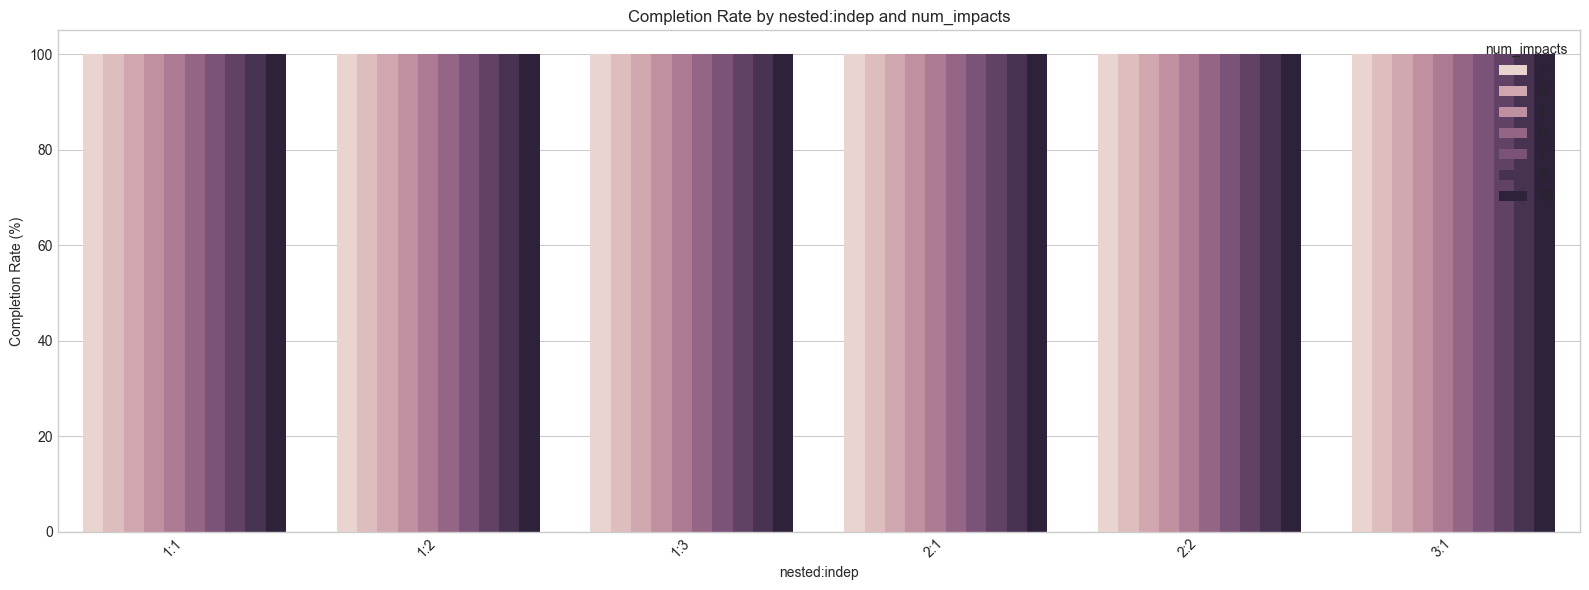

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Completion rate (finished runs: vte is not NaN) differentiated by nested, indep, and num_impacts
df = data[['nested', 'indep', 'num_impacts', 'vte', 'error']].copy()
df['completed'] = df['vte'].notna()

agg = (
    df.groupby(['num_impacts', 'nested', 'indep'])['completed']
      .mean()
      .mul(100)
      .reset_index(name='completion_rate_pct')
)
agg['nested_indep'] = agg['nested'].astype(int).astype(str) + ':' + agg['indep'].astype(int).astype(str)

order_df = (
    agg[['nested', 'indep', 'nested_indep']]
      .drop_duplicates()
      .sort_values(['nested', 'indep'])
)
order = order_df['nested_indep'].tolist()

plt.figure(figsize=(16, 6))
sns.barplot(
    data=agg,
    x='nested_indep',
    y='completion_rate_pct',
    hue='num_impacts',
    order=order,
    errorbar=None,
)
plt.xlabel('nested:indep')
plt.ylabel('Completion Rate (%)')
plt.title('Completion Rate by nested:indep and num_impacts')
plt.xticks(rotation=45, ha='right')
plt.legend(title='num_impacts')
plt.tight_layout()
plt.show()


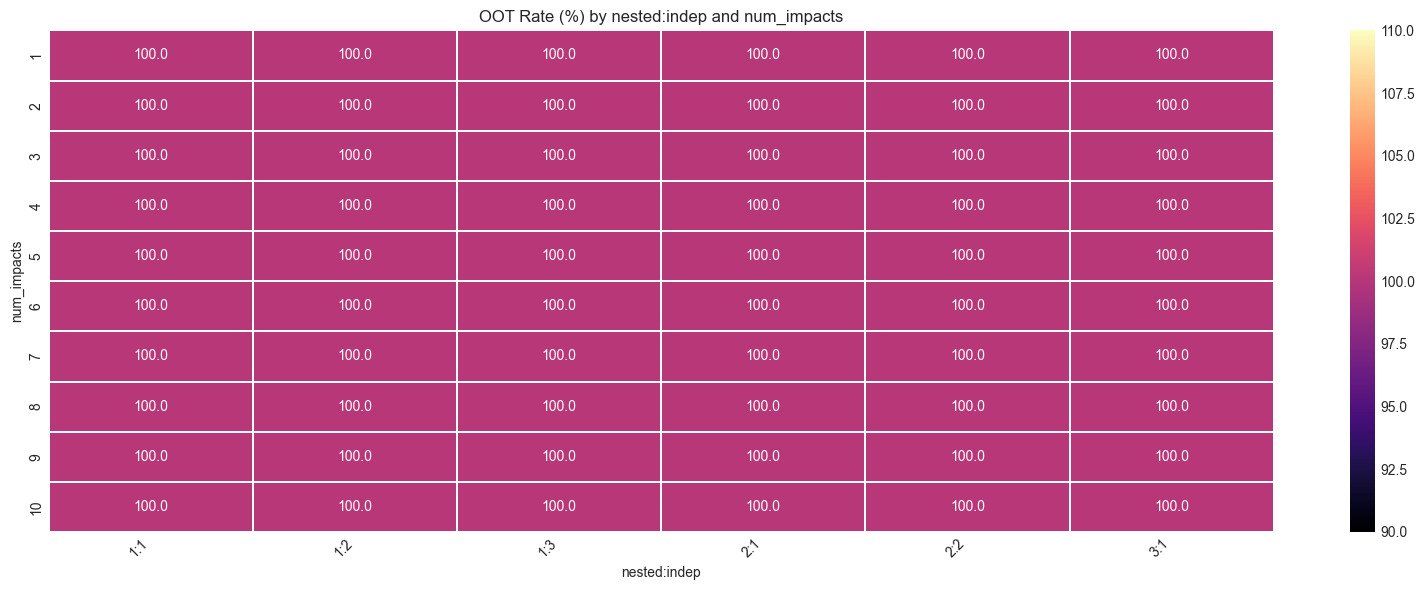

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# OOT rate (error not NaN) as a heatmap over num_impacts and nested:indep
df = data[['nested', 'indep', 'num_impacts', 'error']].copy()
df['oot'] = df['error'].notna().astype(int)

agg = (
    df.groupby(['num_impacts', 'nested', 'indep'])['oot']
      .mean()
      .mul(100)
      .reset_index(name='oot_rate_pct')
)
agg['nested_indep'] = agg['nested'].astype(int).astype(str) + ':' + agg['indep'].astype(int).astype(str)

order = (
    agg[['nested', 'indep', 'nested_indep']]
      .drop_duplicates()
      .sort_values(['nested', 'indep'])['nested_indep']
      .tolist()
)

heatmap_data = agg.pivot(index='num_impacts', columns='nested_indep', values='oot_rate_pct')
heatmap_data = heatmap_data.reindex(columns=order)

plt.figure(figsize=(16, 6))
ax = sns.heatmap(heatmap_data, cmap='magma', linewidths=0.3, annot=True, fmt='.1f')
ax.set_xlabel('nested:indep')
ax.set_ylabel('num_impacts')
ax.set_title('OOT Rate (%) by nested:indep and num_impacts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [7]:
df

,nested,indep,num_impacts,error,oot
0,1,1,1,,1
1,1,1,1,,1
2,1,1,1,,1
3,1,1,1,,1
4,1,1,1,,1
...,...,...,...,...,...
3235,3,1,10,,1
3236,3,1,10,,1
3237,3,1,10,,1
3238,3,1,10,,1


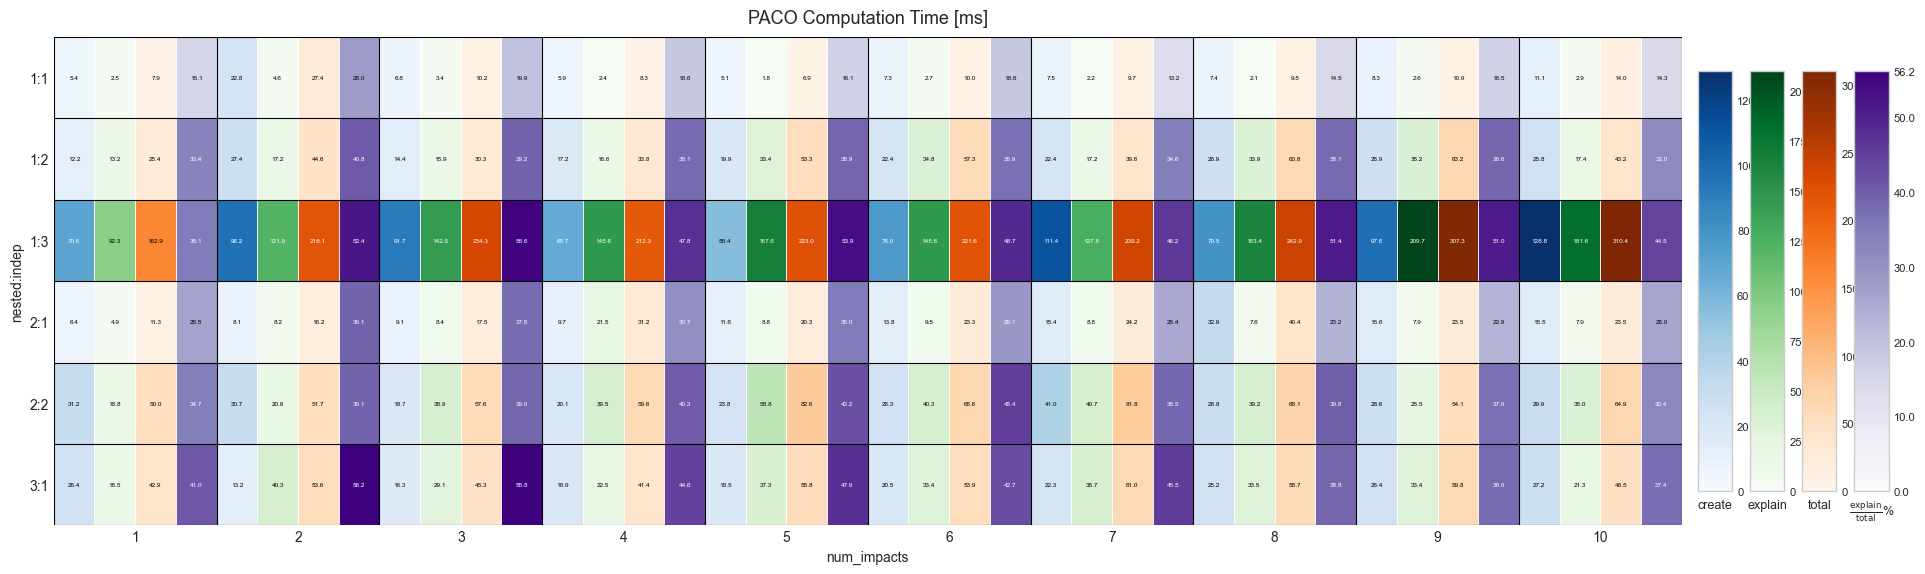

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Mean create/explain/total times plus explanation share, differentiated by nested, indep, and num_impacts
df = data[['nested', 'indep', 'num_impacts',
           'time_create_execution_tree', 'time_evaluate_cei_execution_tree', 'found_strategy_time',
           'build_strategy_time', 'time_explain_strategy', 'strategy_tree_time']].copy()

df['time_create_strategy_ms'] = (
    df['time_create_execution_tree']
    + df['time_evaluate_cei_execution_tree']
    + df['found_strategy_time']
)
df['time_explain_strategy_ms'] = (
    df['build_strategy_time']
    + df['time_explain_strategy']
    + df['strategy_tree_time']
)
df['time_total_ms'] = df['time_create_strategy_ms'] + df['time_explain_strategy_ms']
df['explain_share_pct'] = np.where(
    df['time_total_ms'] > 0,
    100.0 * df['time_explain_strategy_ms'] / df['time_total_ms'],
    np.nan,
)

agg = (
    df.groupby(['num_impacts', 'nested', 'indep'])[
        ['time_create_strategy_ms', 'time_explain_strategy_ms', 'time_total_ms', 'explain_share_pct']
    ]
    .mean()
    .reset_index()
)
agg['nested_indep'] = agg['nested'].astype(int).astype(str) + ':' + agg['indep'].astype(int).astype(str)

order = (
    agg[['nested', 'indep', 'nested_indep']]
      .drop_duplicates()
      .sort_values(['nested', 'indep'])['nested_indep']
      .tolist()
)

metric_specs = [
    ('time_create_strategy_ms', 'Blues', 'create'),
    ('time_explain_strategy_ms', 'Greens', 'explain'),
    ('time_total_ms', 'Oranges', 'total'),
    ('explain_share_pct', 'Purples', '$\\frac{\\mathrm{explain}}{\\mathrm{total}}$%'),
]
impact_order = sorted(agg['num_impacts'].dropna().astype(int).unique().tolist())
heatmaps = {
    metric: agg.pivot(index='nested_indep', columns='num_impacts', values=metric).reindex(index=order, columns=impact_order)
    for metric, _, _ in metric_specs
}
row_labels = order
col_labels = impact_order
nrows = len(row_labels)
ncols = len(col_labels)
band_width = 1.0 / len(metric_specs)

cmaps = {metric: plt.get_cmap(cmap_name) for metric, cmap_name, _ in metric_specs}
norms = {}
for metric, _, _ in metric_specs:
    values = heatmaps[metric].to_numpy(dtype=float)
    vmax = float(np.nanmax(values)) if np.isfinite(values).any() else 1.0
    norms[metric] = mcolors.Normalize(vmin=0.0, vmax=max(vmax, 1e-9))

fig, ax = plt.subplots(figsize=(22, 6.6))
fig.subplots_adjust(left=0.08, right=0.82, bottom=0.14, top=0.88)
cbar_axes = [
    inset_axes(
        ax,
        width='2.1%',
        height='86%',
        loc='lower left',
        bbox_to_anchor=(1.01 + 0.032 * i, 0.07, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    for i in range(len(metric_specs))
]

for i, row in enumerate(row_labels):
    for j, col in enumerate(col_labels):
        for k, (metric, _, _) in enumerate(metric_specs):
            value = heatmaps[metric].loc[row, col]
            x0 = j + k * band_width
            y0 = i
            if pd.isna(value):
                face = (0.95, 0.95, 0.95, 1.0)
            else:
                face = cmaps[metric](norms[metric](float(value)))
            rect = Rectangle((x0, y0), band_width, 1.0, facecolor=face, edgecolor='white', linewidth=0.6)
            ax.add_patch(rect)
            if pd.notna(value):
                r, g, b, _ = face
                luminance = 0.299 * r + 0.587 * g + 0.114 * b
                text_color = 'black' if luminance > 0.62 else 'white'
                label = f'{float(value):.1f}'
                ax.text(
                    x0 + band_width / 2.0,
                    y0 + 0.5,
                    label,
                    ha='center',
                    va='center',
                    fontsize=4.6,
                    rotation=0,
                    color=text_color,
                    clip_on=True,
                )

for x in range(ncols + 1):
    ax.plot([x, x], [0, nrows], color='black', linewidth=0.8)
for y in range(nrows + 1):
    ax.plot([0, ncols], [y, y], color='black', linewidth=0.8)

ax.set_xlim(0, ncols)
ax.set_ylim(0, nrows)
ax.invert_yaxis()
ax.set_xticks(np.arange(ncols) + 0.5)
ax.set_xticklabels([str(int(v)) for v in col_labels], rotation=0)
ax.set_yticks(np.arange(nrows) + 0.5)
ax.set_yticklabels(row_labels)
ax.set_xlabel('num_impacts')
ax.set_ylabel('nested:indep')
ax.set_title('PACO Computation Time [ms]', fontsize=13, pad=10)
for spine in ax.spines.values():
    spine.set_visible(False)

for cax, (metric, _, label) in zip(cbar_axes, metric_specs):
    sm = ScalarMappable(norm=norms[metric], cmap=cmaps[metric])
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
    cbar.ax.yaxis.label.set_visible(False)
    cbar.ax.xaxis.set_label_position('bottom')
    cbar.ax.set_xlabel(label, fontsize=9, labelpad=6)
    cbar.ax.tick_params(labelsize=8)
    if metric == 'explain_share_pct':
        ticks = np.asarray(cbar.get_ticks(), dtype=float)
        vmax = float(norms[metric].vmax)
        ticks = ticks[(ticks >= 0.0) & (ticks <= vmax)]
        if ticks.size == 0 or not np.isclose(ticks[-1], vmax):
            ticks = np.append(ticks, vmax)
        ticks = np.unique(np.round(ticks, 6))
        cbar.set_ticks(ticks)

plt.savefig('validation/results/mean_times_nested_indep_num_impacts.pdf', format='pdf', bbox_inches='tight')
plt.savefig('validation/results/mean_times_nested_indep_num_impacts.png', dpi=220, bbox_inches='tight')
plt.show()


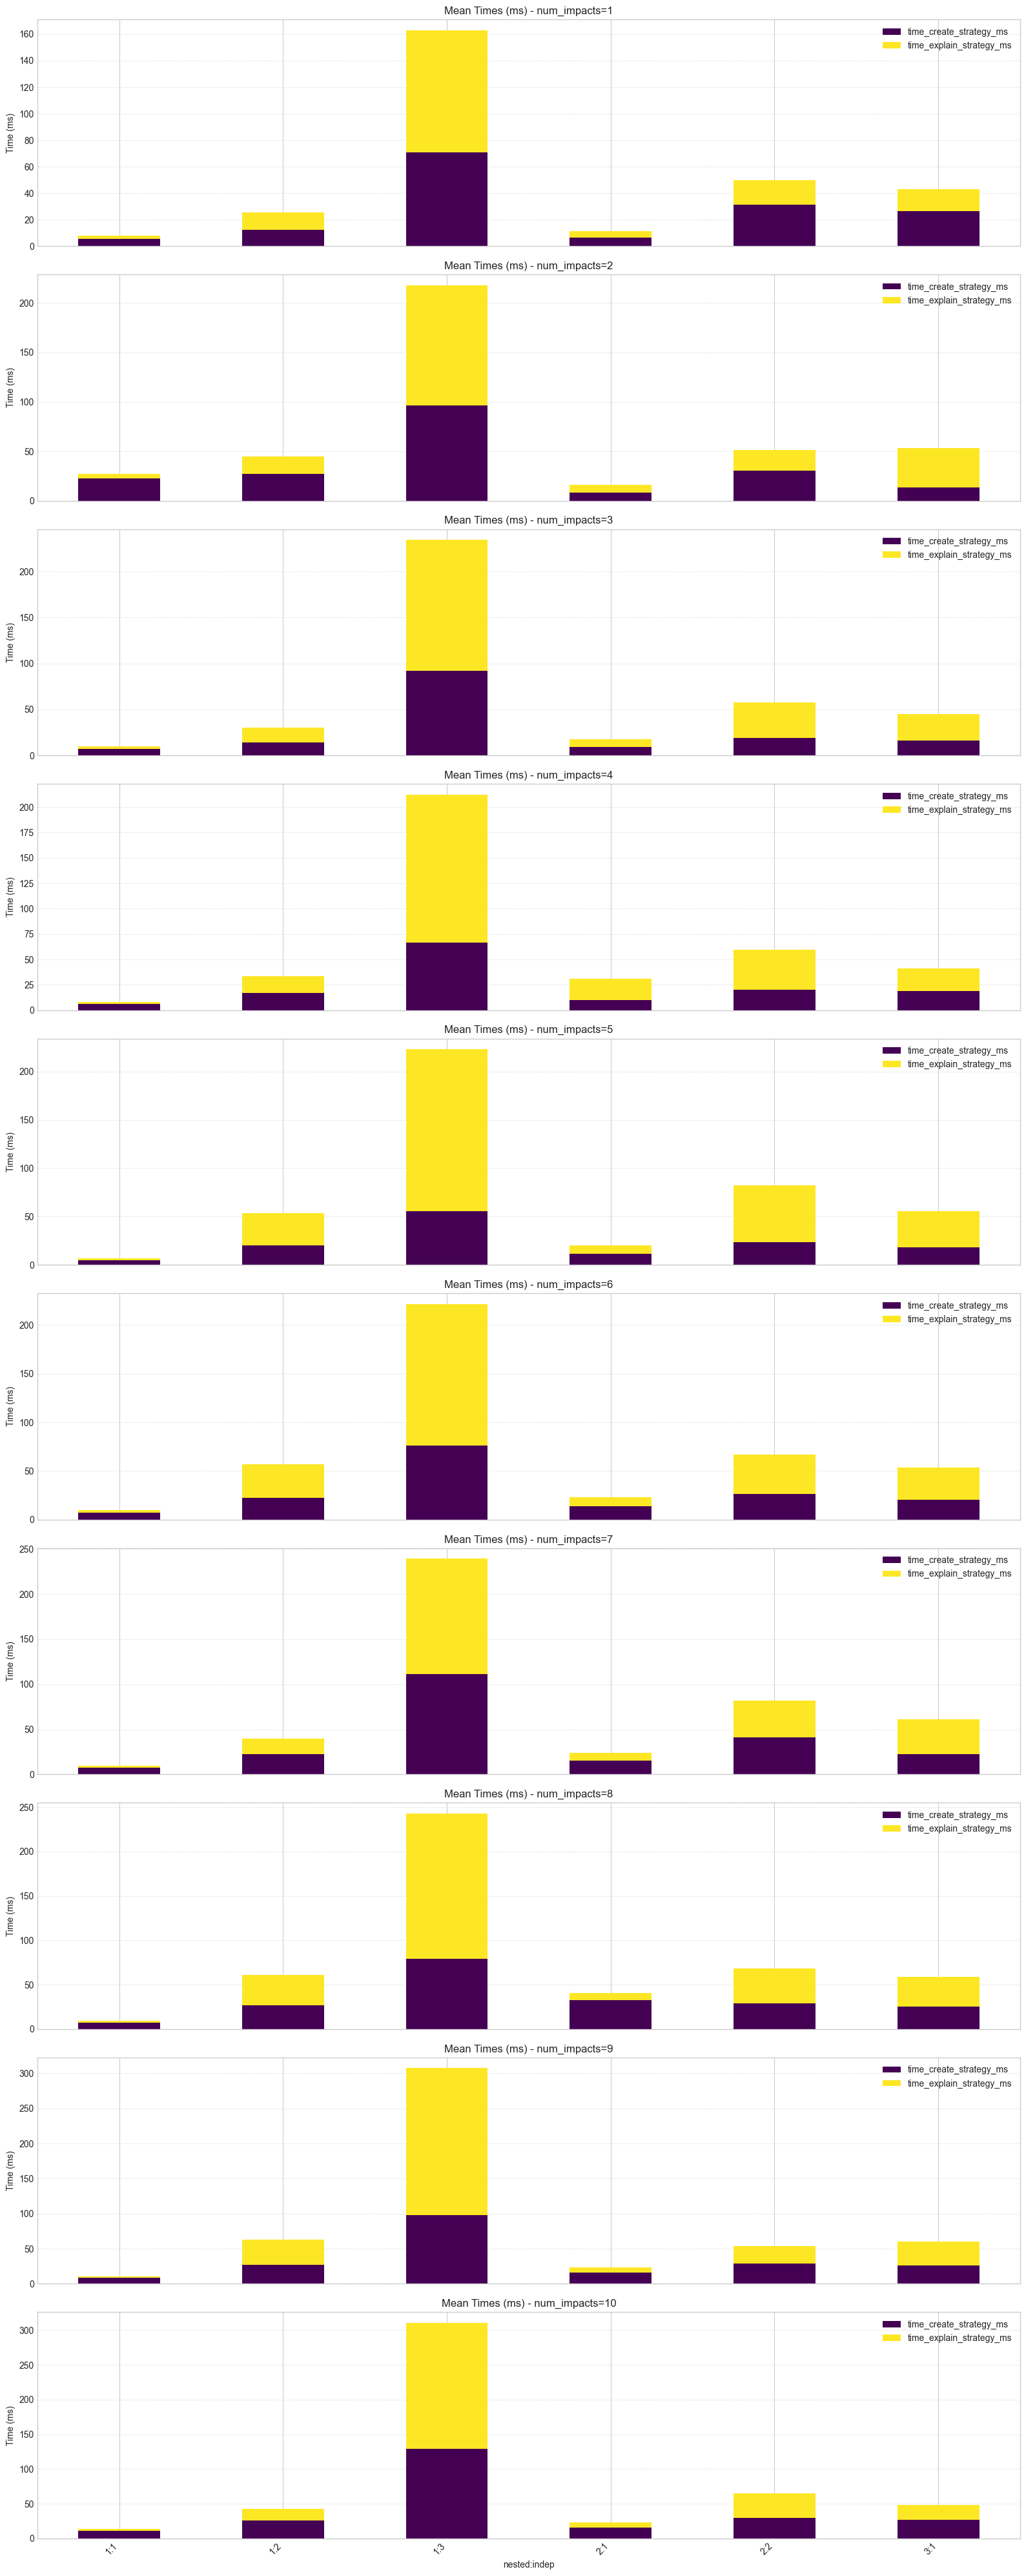

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Stacked create/explain comparison for each num_impacts level
df = data[['nested', 'indep', 'num_impacts',
           'time_create_execution_tree', 'time_evaluate_cei_execution_tree', 'found_strategy_time',
           'build_strategy_time', 'time_explain_strategy', 'strategy_tree_time']].copy()

df['time_create_strategy_ms'] = (
    df['time_create_execution_tree']
    + df['time_evaluate_cei_execution_tree']
    + df['found_strategy_time']
)
df['time_explain_strategy_ms'] = (
    df['build_strategy_time']
    + df['time_explain_strategy']
    + df['strategy_tree_time']
)

agg = (
    df.groupby(['num_impacts', 'nested', 'indep'])[['time_create_strategy_ms', 'time_explain_strategy_ms']]
      .mean()
      .reset_index()
)
agg['nested_indep'] = agg['nested'].astype(int).astype(str) + ':' + agg['indep'].astype(int).astype(str)

order = (
    agg[['nested', 'indep', 'nested_indep']]
      .drop_duplicates()
      .sort_values(['nested', 'indep'])['nested_indep']
      .tolist()
)

num_impacts_values = sorted(agg['num_impacts'].dropna().unique())
fig, axes = plt.subplots(len(num_impacts_values), 1, figsize=(16, 4 * len(num_impacts_values)), sharex=True)
if len(num_impacts_values) == 1:
    axes = [axes]

for ax, ni in zip(axes, num_impacts_values):
    subset = agg[agg['num_impacts'] == ni].copy()
    subset = subset.set_index('nested_indep').reindex(order)
    subset[['time_create_strategy_ms', 'time_explain_strategy_ms']].plot(
        kind='bar', stacked=True, ax=ax, colormap='viridis'
    )
    ax.set_title(f'Mean Times (ms) - num_impacts={int(ni)}')
    ax.set_ylabel('Time (ms)')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('nested:indep')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('validation/results/bartime_contribution_mean.pdf', format='pdf')
plt.savefig('validation/results/bartime_contribution_mean.png', dpi=200)
plt.show()


## Heatmaps

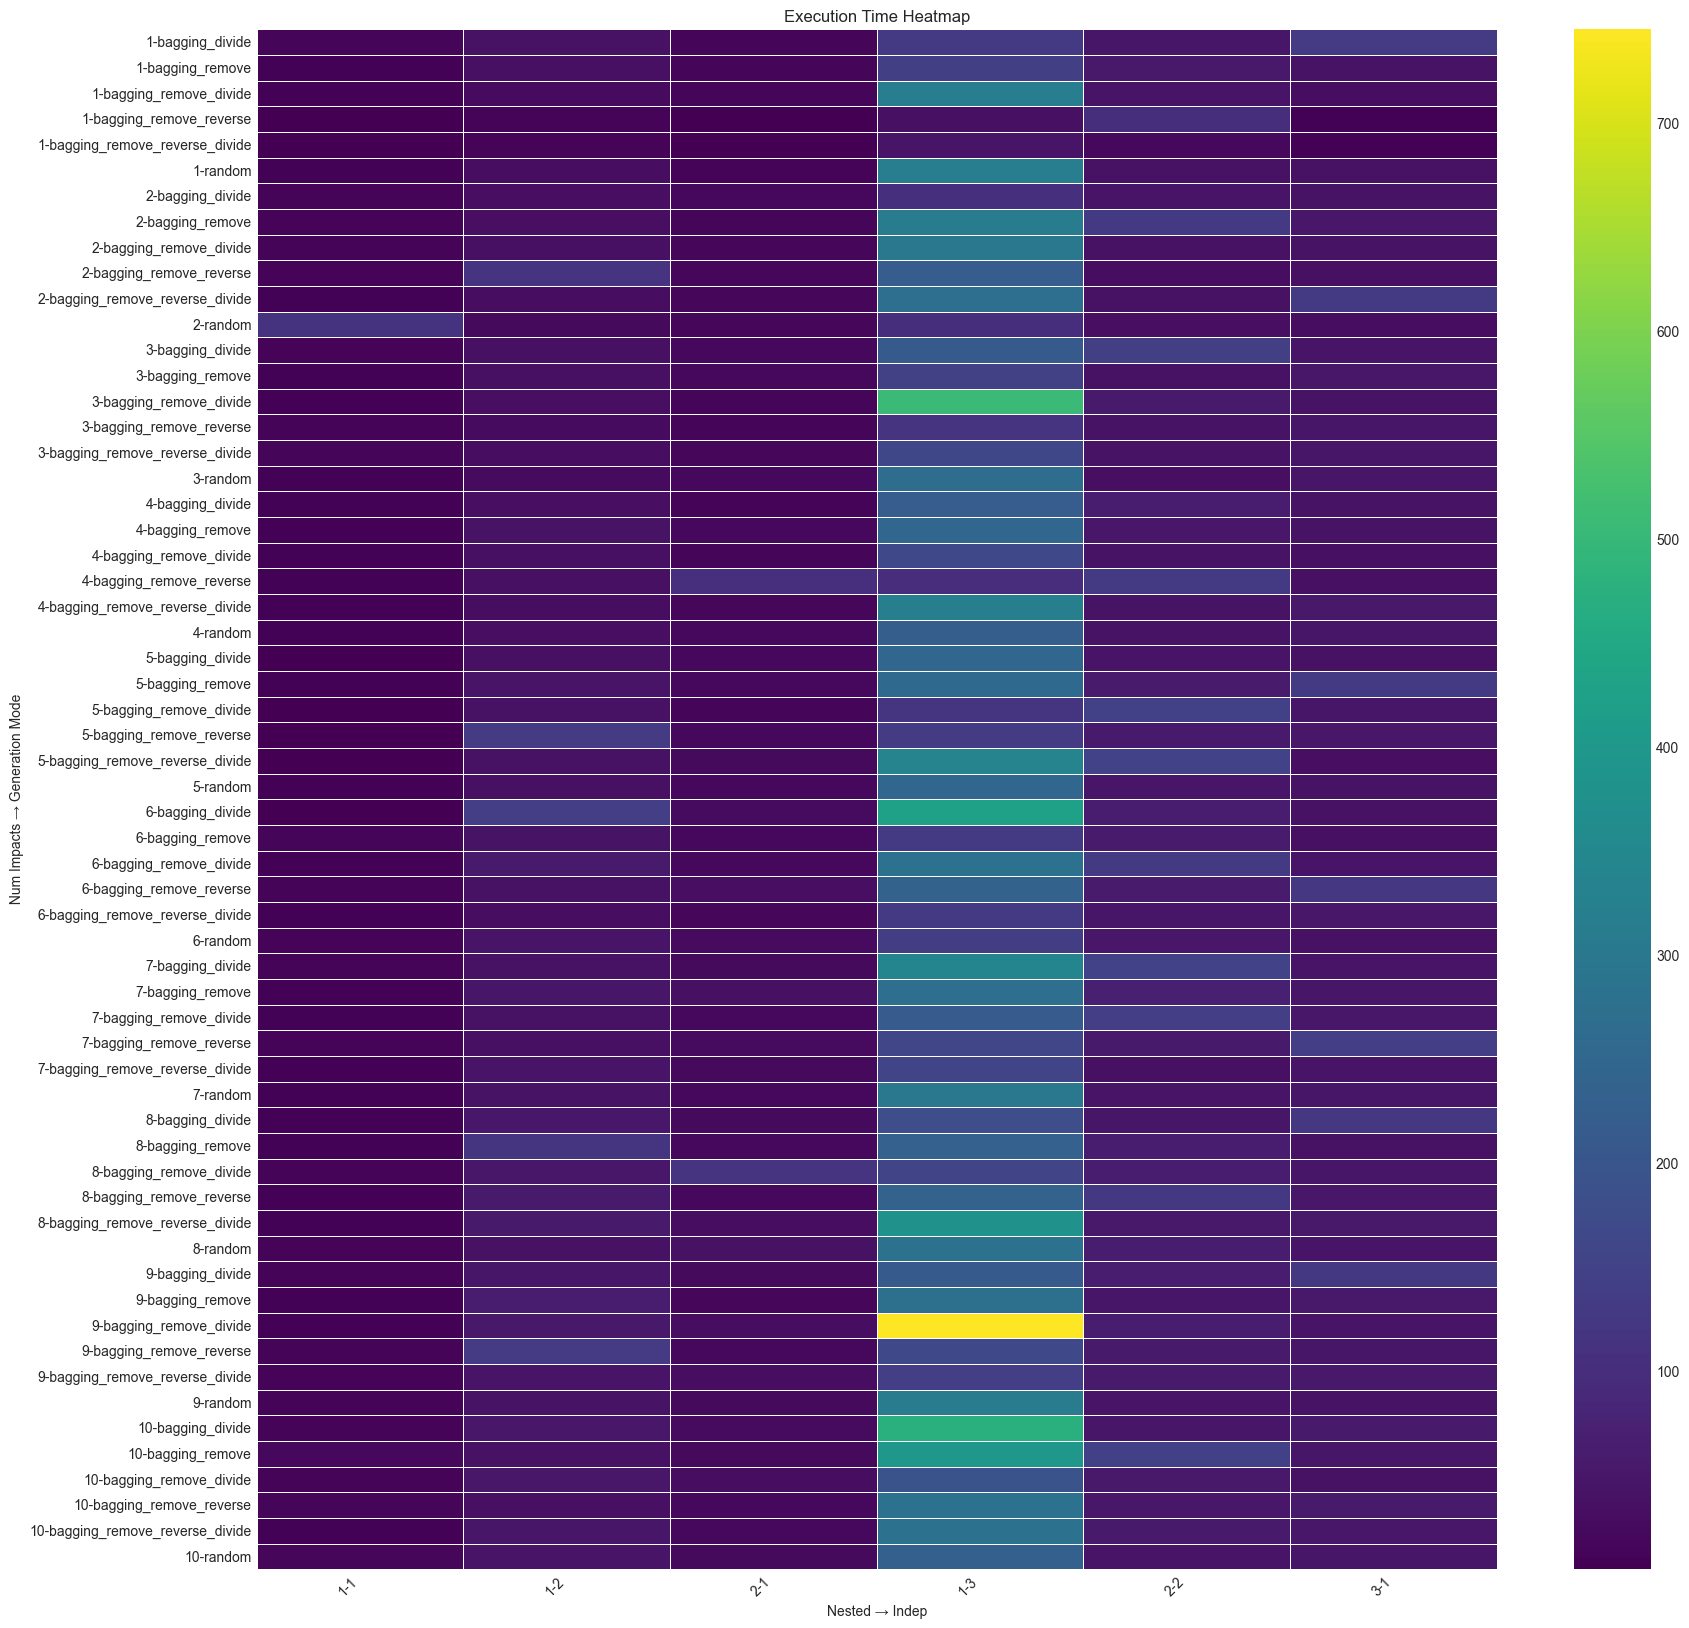

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns
df = data[['nested', 'generation_mode', "indep", "num_impacts"]]

df['strategy_tree_time']  = data[[ 'time_create_execution_tree', 'time_evaluate_cei_execution_tree', 'found_strategy_time',
'build_strategy_time', 'time_explain_strategy', 'strategy_tree_time']].copy().sum(axis=1)
# print(df_t.head())

# Aggregate duplicate combinations by taking the mean
df_grouped = df.groupby(['generation_mode', 'num_impacts', 'nested', 'indep']).strategy_tree_time.mean().reset_index()

# Compute the sum of nested + indep for ordering
df_grouped['nested_indep_sum'] = df_grouped['nested'] + df_grouped['indep']

# Pivot table with multi-level x-axis (nested, indep) and y-axis (generation_mode, num_impacts)
heatmap_data = df_grouped.pivot(index=['num_impacts', 'generation_mode'], columns=['nested', 'indep'], values='strategy_tree_time')

# Order the columns based on the sum of (nested + indep)
sorted_columns = sorted(heatmap_data.columns, key=lambda x: x[0] + x[1])  # Sorting by sum of (nested, indep)

# Reorder the pivot table columns
heatmap_data = heatmap_data[sorted_columns]

# Plot heatmap
plt.figure(figsize=(20, 20))
ax = sns.heatmap(heatmap_data, cmap="viridis", linewidth=0.5, annot=False, fmt=".2f")

# Labels and title
plt.xlabel("Nested → Indep")
plt.ylabel(" Num Impacts → Generation Mode")
plt.title("Execution Time Heatmap")

# Adjust x-axis and y-axis formatting
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # Rotate x labels for readability
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Keep y labels readable
plt.show()

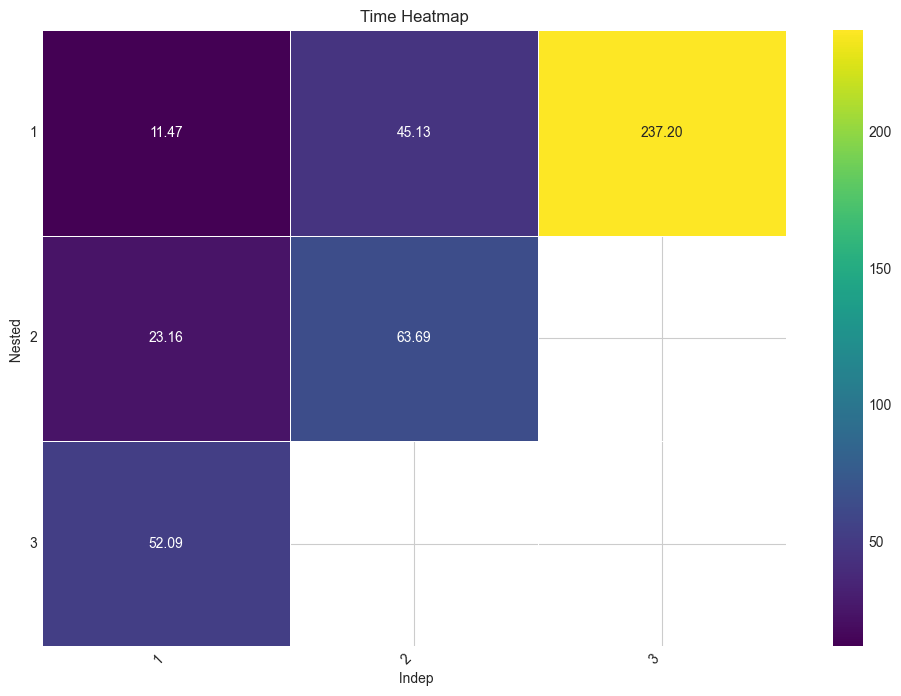

In [11]:
df_grouped = df.groupby(['nested', 'indep']).strategy_tree_time.mean().reset_index()

heatmap_data = df_grouped.pivot(index=['nested'], columns=[ 'indep'], values='strategy_tree_time')

# Plot heatmap
plt.figure(figsize=(12, 8))
ax = sns.heatmap(heatmap_data, cmap="viridis", linewidth=0.5, annot=True, fmt=".2f")

# Labels and title
plt.xlabel(" Indep")
plt.ylabel(" Nested  ")
plt.title("Time Heatmap")

# Adjust x-axis and y-axis formatting
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # Rotate x labels for readability
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  
# Show the plot
plt.show()

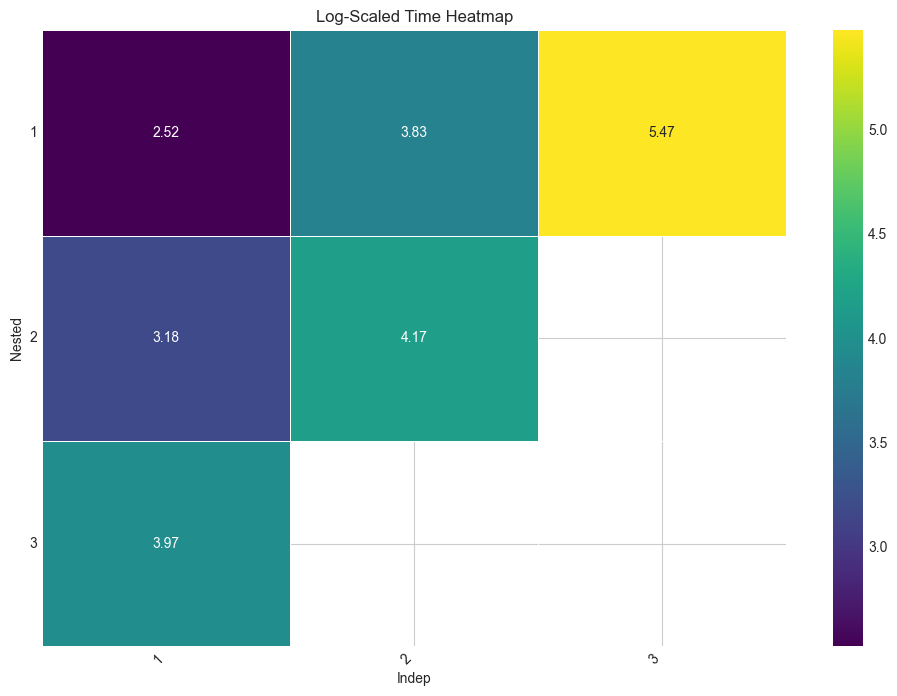

In [12]:
df_grouped['strategy_tree_time_log'] = np.log1p(df_grouped['strategy_tree_time'])

# Pivot table for heatmap
heatmap_data = df_grouped.pivot(index='nested', columns='indep', values='strategy_tree_time_log')

# Plot heatmap
plt.figure(figsize=(12, 8))
ax = sns.heatmap(heatmap_data, cmap="viridis", linewidth=0.5, annot=True, fmt=".2f")

# Labels and title
plt.xlabel("Indep")
plt.ylabel("Nested")
plt.title("Log-Scaled Time Heatmap")

# Adjust x-axis and y-axis formatting
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.show()

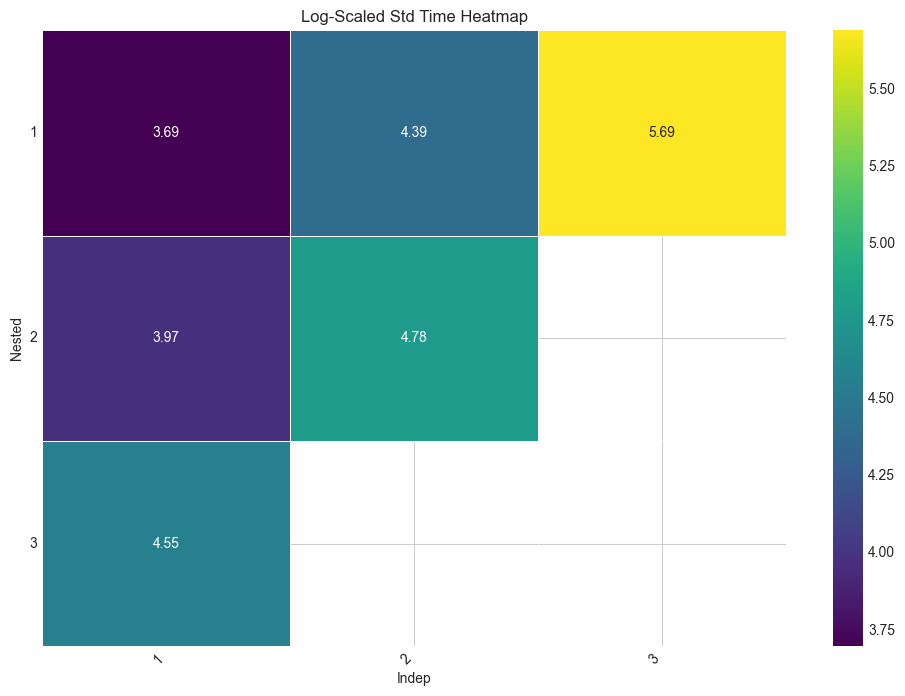

In [13]:
# Grouping by 'nested' and 'indep', calculating mean & std
df_grouped = df.groupby(['nested', 'indep']).strategy_tree_time.agg(['mean', 'std']).reset_index()

# Apply log transformation to avoid issues with zero values
df_grouped['strategy_tree_time_log_mean'] = np.log1p(df_grouped['mean'])
df_grouped['strategy_tree_time_log_std'] = np.log1p(df_grouped['std'])  # Log of std as well

# Pivot tables for heatmaps
heatmap_data_mean = df_grouped.pivot(index='nested', columns='indep', values='strategy_tree_time_log_mean')
heatmap_data_std = df_grouped.pivot(index='nested', columns='indep', values='strategy_tree_time_log_std')


# Plot heatmap
plt.figure(figsize=(12, 8))
ax = sns.heatmap(heatmap_data_std, cmap="viridis", linewidth=0.5, annot=True, fmt=".2f")

# Labels and title
plt.xlabel("Indep")
plt.ylabel("Nested")
plt.title("Log-Scaled Std Time Heatmap")

# Adjust x-axis and y-axis formatting
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
# Show the plot
plt.show()

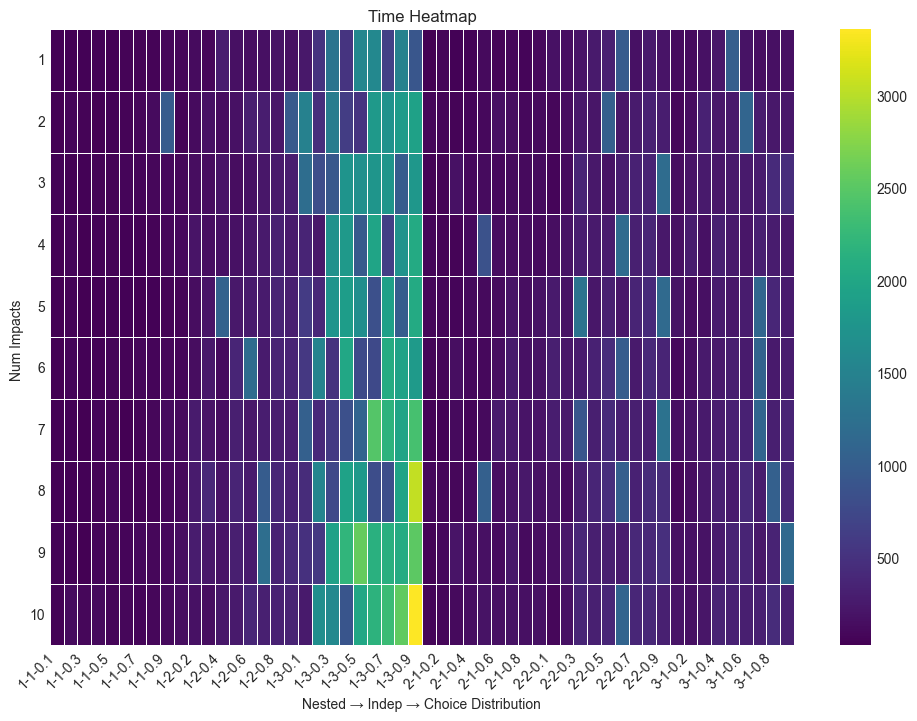

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sum the time-related columns per row
df_times = data[['time_create_execution_tree', 'time_evaluate_cei_execution_tree', 
                 'found_strategy_time', 'build_strategy_time', 
                 'time_explain_strategy', 'strategy_tree_time']].sum(axis=1)

# Extract relevant columns and assign the summed times correctly
df = data[['nested', "choice_distribution","indep", "num_impacts"]].copy()
df['strategy_tree_time'] = df_times  # Correctly assign summed times per row

# Aggregate duplicate combinations by summing their times
df_grouped = df.groupby([ 'num_impacts', 'nested', 'indep',"choice_distribution"]).strategy_tree_time.sum().reset_index()

# Pivot table with a multi-level x-axis: (nested, indep) and multi-level y-axis: (generation_mode, num_impacts)
heatmap_data = df_grouped.pivot(index=['num_impacts'], columns=['nested', 'indep', "choice_distribution",], values='strategy_tree_time')

# Plot heatmap
plt.figure(figsize=(12, 8))
ax = sns.heatmap(heatmap_data, cmap="viridis", linewidth=0.5, annot=False, fmt=".2f")

# Labels and title
plt.xlabel("Nested → Indep → Choice Distribution")
plt.ylabel("Num Impacts ")
plt.title("Time Heatmap")

# Adjust x-axis and y-axis formatting
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # Rotate x labels for readability
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Keep y labels readable
plt.savefig('times_heatmap_no_generation_methods.svg', format='svg')
# Show the plot
plt.show()


## Time Heatmap of BPMN+CPI Complexity ("Nested → Indep → Choice Distribution") vs Impacts ("Num Impacts → Generation Mode ")

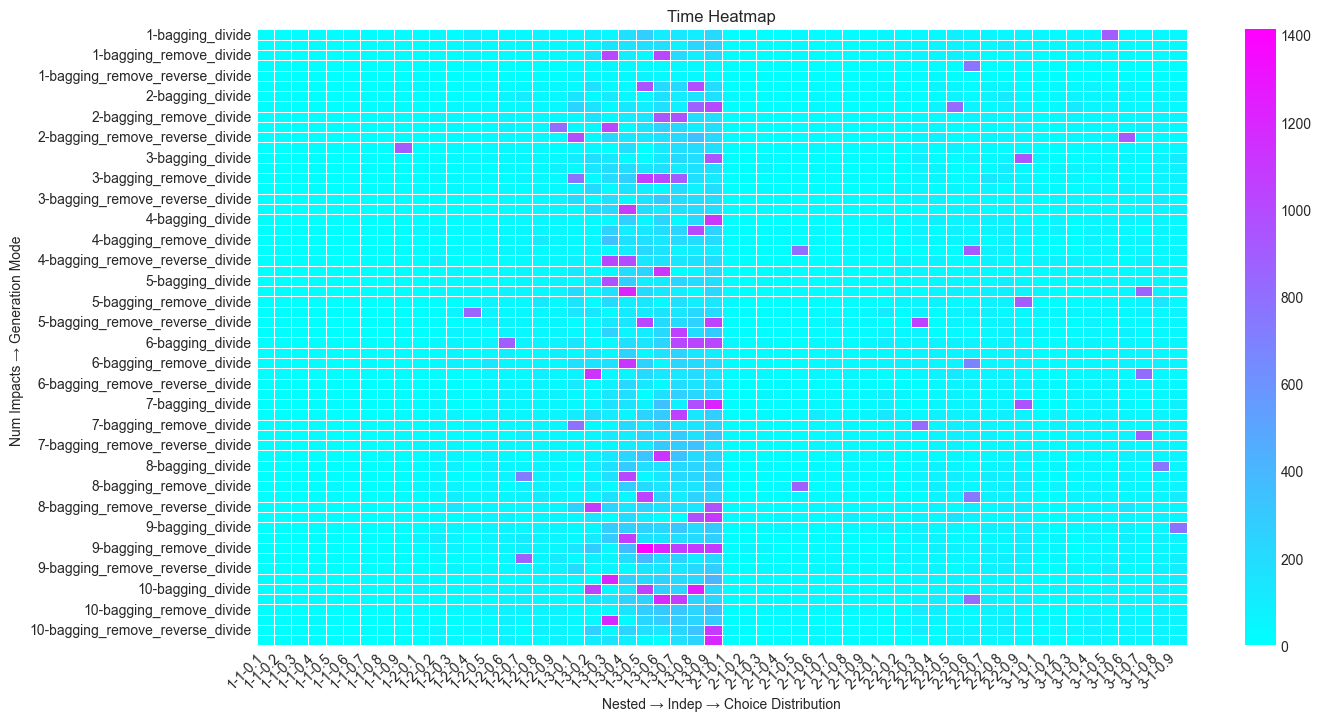

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# # Sum the time-related columns per row
df_times = data[['time_create_execution_tree', 'time_evaluate_cei_execution_tree', 
                 'found_strategy_time', 'build_strategy_time', 
                 'time_explain_strategy', 'strategy_tree_time']].sum(axis=1)

# Extract relevant columns and assign the summed times correctly
df = data[['nested', 'generation_mode', "choice_distribution","indep", "num_impacts",
           # 'time_create_execution_tree', 'time_evaluate_cei_execution_tree', 
           #       'found_strategy_time', 'build_strategy_time', 
           #       'time_explain_strategy', 'strategy_tree_time'
          ]].copy()
df['strategy_tree_time'] = df_times  # Correctly assign summed times per row

# Aggregate duplicate combinations by summing their times
df_grouped = df.groupby(['generation_mode', 'num_impacts', 'nested', 'indep',"choice_distribution"]).strategy_tree_time.mean().reset_index()

# Pivot table with a multi-level x-axis: (nested, indep) and multi-level y-axis: (generation_mode, num_impacts)
heatmap_data = df_grouped.pivot(index=['num_impacts', 'generation_mode'], columns=['nested', 'indep', "choice_distribution",], values='strategy_tree_time')
# heatmap_data = heatmap_data.fillna(0)
# print(heatmap_data.values.isna().any())
# Plot heatmap
plt.figure(figsize=(15, 8))
ax = sns.heatmap(heatmap_data, cmap="cool", linewidth=0.5, annot=False, fmt=".2f")

# Labels and title
plt.xlabel("Nested → Indep → Choice Distribution")
plt.ylabel("Num Impacts → Generation Mode ")
plt.title("Time Heatmap")

# Adjust x-axis and y-axis formatting
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # Rotate x labels for readability
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Keep y labels readable
# Show the plot
plt.show()

### Heatmap Detailed

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevantdata
df = data[['nested', 'generation_mode', "indep", "num_impacts"]]

df['strategy_time']  = data[[ 'time_create_execution_tree', 'time_evaluate_cei_execution_tree', 'found_strategy_time',
]].copy().sum(axis=1)
df['explainer_time']  = data[[ 'build_strategy_time', 'time_explain_strategy', 'strategy_tree_time']].copy().sum(axis=1)


In [17]:
# Aggregate duplicate combinations by taking the mean
df_grouped = df.groupby(['generation_mode', 'num_impacts', 'nested', 'indep']).explainer_time.mean().reset_index()

# Compute the sum of nested + indep for ordering
df_grouped['nested_indep_sum'] = df_grouped['nested'] + df_grouped['indep']

# Filter by complexity & impacts


df_grouped = df_grouped[
    # nested_indep_sum is nested + indep 2-20
    (df_grouped['nested_indep_sum']>=6) & 
    # dimension of the impact vector 1-10
    (df_grouped['num_impacts']>=6)
    
]

In [18]:
if df_grouped.empty:
    print("Skipping heatmap: no rows after filters (nested+indep >= 6 and num_impacts >= 6).")
else:
    heatmap_data = df_grouped.pivot(index=['num_impacts', 'generation_mode'], columns=['nested', 'indep'], values='explainer_time')

    # Order the columns based on the sum of (nested + indep)
    sorted_columns = sorted(heatmap_data.columns, key=lambda x: x[0] + x[1])  # Sorting by sum of (nested, indep)

    # Reorder the pivot table columns
    heatmap_data = heatmap_data[sorted_columns]

    if heatmap_data.empty or heatmap_data.notna().sum().sum() == 0:
        print("Skipping heatmap: pivot produced no plottable values.")
    else:
        # Plot heatmap
        plt.figure(figsize=(15, 20))
        # If you want to plot the data put annot=True, False otherwise
        ax = sns.heatmap(heatmap_data, cmap="viridis", linewidth=0.5, annot=False, fmt=".2f")

        # Labels and title
        plt.xlabel("Nested → Indep")
        plt.ylabel(" Num Impacts → Generation Mode")
        plt.title("Execution Time Heatmap")
        plt.tight_layout(rect=[0, 0, 1, 1])
        # Adjust x-axis and y-axis formatting
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # Rotate x labels for readability
        # ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Keep y labels readable
        SMALL_SIZE = 28

        plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
        plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
        plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
        plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
        plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
        plt.rc('legend', fontsize=SMALL_SIZE*1.5)    # legend fontsize
        plt.rc('figure', titlesize=SMALL_SIZE)
        # Show the plot
        plt.show()


Skipping heatmap: no rows after filters (nested+indep >= 6 and num_impacts >= 6).


## Execution Time Heatmap: BPMN+CPI Complexity ("Nested:Indep") vs. Choice Distribution

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Compute summed times across all relevant columns
df_times = data[['time_create_execution_tree', 'time_evaluate_cei_execution_tree', 
                 'found_strategy_time', 'build_strategy_time', 
                 'time_explain_strategy', 'strategy_tree_time']].sum(axis=1)

# Extract relevant columns
df = data[['nested', "choice_distribution", "indep", "num_impacts"]].copy()

# Assign the computed strategy tree time
df['strategy_tree_time'] = df_times

# Compute the sum of nested + indep for ordering
df['nested_indep_sum'] = df['nested'] + df['indep']

# Create a 'nested:indep' column
df['nested_indep'] = df['nested'].astype(str) + "-" + df['indep'].astype(str)

# Aggregate duplicate combinations by taking the mean of strategy_tree_time
df_grouped = df.groupby(['num_impacts', 'nested_indep', 'nested_indep_sum', 'choice_distribution'])['strategy_tree_time'].mean().reset_index()
# 
# Sort by sum of nested + indep
df_grouped = df_grouped.sort_values(by="nested_indep_sum")
df_grouped = df_grouped[(df_grouped['nested_indep_sum']>= 5)]

if df_grouped.empty:
    print("Skipping heatmap: no rows after nested_indep_sum filter.")
else:
    # Sort the 'nested_indep' values based on 'nested_indep_sum' (ensure the columns are in order)
    df_grouped['nested_indep'] = pd.Categorical(df_grouped['nested_indep'], 
                                                categories=df_grouped.sort_values('nested_indep_sum')['nested_indep'].unique(), 
                                                ordered=True)

    # Pivot the data for heatmap (choice_distribution vs nested_indep ordered)
    heatmap_data = df_grouped.pivot_table(index='choice_distribution', 
                                          columns='nested_indep', 
                                          values='strategy_tree_time', 
                                          aggfunc='mean')  # Ensures uniqueness

    if heatmap_data.empty or heatmap_data.notna().sum().sum() == 0:
        print("Skipping heatmap: pivot produced no plottable values.")
    else:
        # Plot the heatmap
        plt.figure(figsize=(12, 8))
        sns.heatmap(heatmap_data, cmap="viridis", annot=False, fmt=".2f", linewidths=0.5)

        # Labels and title
        plt.ylabel("Choice Distribution")
        plt.xlabel("Nested:Indep")
        plt.title("Execution Time Heatmap")

        # Font size settings
        SMALL_SIZE = 24
        MEDIUM_SIZE = 10
        BIGGER_SIZE = 12

        plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
        plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
        plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
        plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
        plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
        plt.rc('legend', fontsize=SMALL_SIZE*1.5)    # legend fontsize
        plt.rc('figure', titlesize=SMALL_SIZE)
        # Show the plot
        plt.show()


Skipping heatmap: no rows after nested_indep_sum filter.


## 3D plotting

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# Compute summed times across all relevant columns
df_times = data[['time_create_execution_tree', 'time_evaluate_cei_execution_tree', 
                 'found_strategy_time', 'build_strategy_time', 
                 'time_explain_strategy', 'strategy_tree_time']].sum(axis=1)

# Extract relevant columns
df = data[['nested', "choice_distribution", "indep", "num_impacts"]].copy()

# Assign the computed strategy tree time
df['strategy_tree_time'] = df_times

# Compute the sum of nested + indep for ordering
df['nested_indep_sum'] = df['nested'] + df['indep']

# Create a 'nested:indep' column
df['nested_indep'] = df['nested'].astype(str) + ":" + df['indep'].astype(str)

# Aggregate duplicate combinations by taking the mean of strategy_tree_time
df_grouped = df.groupby(['num_impacts', 'nested_indep', 'nested_indep_sum', 'choice_distribution'])['strategy_tree_time'].mean().reset_index()

# Sort by sum of nested + indep
df_grouped = df_grouped.sort_values(by="nested_indep_sum")

# Convert 'nested_indep' to a numeric factor while preserving order
df_grouped["nested_indep_code"] = pd.factorize(df_grouped["nested_indep"])[0]
df_grouped["nested_indep_code"] = pd.to_numeric(df_grouped["nested_indep_code"], errors="coerce")

df_grouped = df_grouped[
        (df_grouped["nested_indep_code"] >= 9) 
         # & (df_grouped["nested_indep_code"] <= 13)
    ]

if len(df_grouped) < 3:
    print("Skipping 3D surface: fewer than 3 points after filtering.")
else:
    # Set axes
    x = df_grouped["choice_distribution"]  # X-axis
    y = df_grouped["nested_indep_code"]  # Y-axis (Categorical converted to numeric)
    z = df_grouped["strategy_tree_time"]  # Z-axis
    c = df_grouped["strategy_tree_time"]  # Color mapping

    # Create the figure and 3D axis
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Create a surface plot using triangulation
    try:
        ax.plot_trisurf(x, y, z, cmap="viridis", alpha=0.7)
    except Exception as exc:
        print(f"Skipping 3D surface ({exc}); showing scatter instead.")
        ax.scatter(x, y, z, c=c, cmap="viridis", s=30)

    SMALL_SIZE = 15
    # Labels
    ax.set_xlabel("Choice Distribution", fontsize = SMALL_SIZE)
    ax.set_ylabel("BPMN+CPI complexity",  fontsize = SMALL_SIZE)
    ax.set_zlabel("Execution Time",  fontsize = SMALL_SIZE)
    ax.set_title("Time vs BPMN+CPI complexity vs Choice Distribution",  fontsize = SMALL_SIZE*1.5)
    # Font size settings

    # Show the plot
    # Show the plot
    plt.show()


Skipping 3D surface: fewer than 3 points after filtering.


In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

df_times = data[['time_create_execution_tree', 'time_evaluate_cei_execution_tree', 
                 'found_strategy_time', 'build_strategy_time', 
                 'time_explain_strategy', 'strategy_tree_time']].sum(axis=1)

# # Extract relevant columns and assign the summed times correctly
df = data[['nested', "choice_distribution", "indep", "num_impacts", 
           # 'time_create_execution_tree', 'time_evaluate_cei_execution_tree', 
           # 'found_strategy_time', 'build_strategy_time', 
           # 'time_explain_strategy', 'strategy_tree_time'
          ]].copy()

# # Calculate summed strategy tree time
df['strategy_tree_time'] = df_times  # Correctly assign summed times per row

# Create a combined column for nested and indep
df['nested_indep'] = df['nested'].astype(str) + ":" + df['indep'].astype(str)

# Use factorize to convert the 'nested_indep' string into numeric values
df['nested_indep_code'] = pd.factorize(df['nested_indep'])[0]

# Aggregate duplicate combinations by summing their times
df_grouped = df.groupby(['num_impacts', 'nested_indep_code', 'choice_distribution']).strategy_tree_time.mean().reset_index()


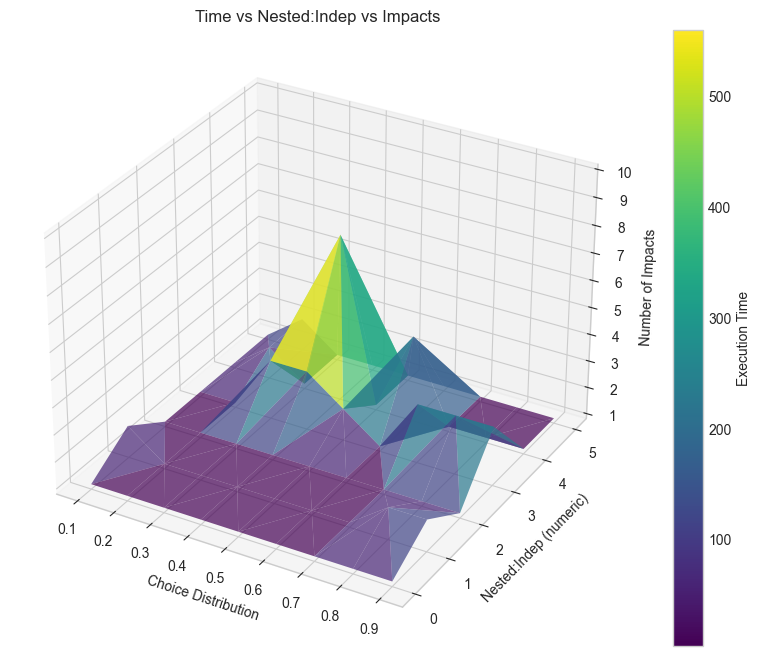

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

if len(df_grouped) < 3:
    print("Skipping 3D surface: fewer than 3 points after filtering.")
else:
    # Set axes
    x = df_grouped["choice_distribution"]  # X-axis
    y = df_grouped["nested_indep_code"]  # Y-axis (Categorical converted to numeric)
    z = df_grouped["num_impacts"]  # Z-axis
    c = df_grouped["strategy_tree_time"]  # Color mapping

    # Create the figure and 3D axis
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Create a surface plot using triangulation
    try:
        ax.plot_trisurf(x, y, z, cmap="viridis", alpha=0.7)
    except Exception as exc:
        print(f"Skipping 3D surface ({exc}); showing scatter instead.")
        ax.scatter(x, y, z, c=c, cmap="viridis", s=30)

    # Labels
    ax.set_xlabel("Choice Distribution")
    ax.set_ylabel("Nested:Indep (numeric)")
    ax.set_zlabel("Number of Impacts")
    ax.set_title("Time vs Nested:Indep vs Impacts")

    # Color bar for reference
    mappable = plt.cm.ScalarMappable(cmap="viridis")
    mappable.set_array(c)
    fig.colorbar(mappable, ax=ax, label="Execution Time")
    plt.show()


# PRISM vs STORM vs PACO

In the following, we propose the validation against the model checker PRISM & STROM

from pony.orm import Database
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/danielamadori/Projects/PACO")
prism_candidates = [
    ROOT / "validation/results/benchmarks_prism.sqlite",
    Path("benchmarks_prism.sqlite"),
]
prism_path = next((p for p in prism_candidates if p.exists()), None)

if prism_path is None:
    print(f"PRISM DB not found; continuing with empty dataframe. candidates={prism_candidates}")
    dataP = pd.DataFrame(columns=[
        'nested','indep','w','z','num_impacts','choice_distribution','generation_mode',
        'duration_interval_min','duration_interval_max','vts','vte','initial_bounds','final_bounds','error'
    ])
    dataP['prism_time'] = pd.Series(dtype='float64')
else:
    db1 = Database()
    db1.bind(provider='sqlite', filename=str(prism_path), create_db=False)

    rowsP = db1.execute("SELECT * FROM experiments")
    columnsP = [row[1] for row in db1.execute("PRAGMA table_info(experiments)")]
    dataP = pd.DataFrame(rowsP, columns=columnsP)

    rename_map = {}
    if 'x' in dataP.columns and 'nested' not in dataP.columns:
        rename_map['x'] = 'nested'
    if 'y' in dataP.columns and 'indep' not in dataP.columns:
        rename_map['y'] = 'indep'
    if 'variant' in dataP.columns and 'z' not in dataP.columns:
        rename_map['variant'] = 'z'
    if rename_map:
        dataP = dataP.rename(columns=rename_map)

    dataP['prism_time'] = (pd.to_datetime(dataP['vte']) - pd.to_datetime(dataP['vts'])).dt.total_seconds() * 1000
    print(f"Using PRISM DB: {prism_path} | Rows: {len(dataP)}")

In [23]:
from pony.orm import Database
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/danielamadori/Projects/PACO")
prism_candidates = [
    ROOT / "validation/results/benchmarks_prism.sqlite",
    Path("benchmarks_prism.sqlite"),
]
prism_path = next((p for p in prism_candidates if p.exists()), None)

if prism_path is None:
    print(f"PRISM DB not found; continuing with empty dataframe. candidates={prism_candidates}")
    dataP = pd.DataFrame(columns=[
        'nested','indep','w','z','num_impacts','choice_distribution','generation_mode',
        'duration_interval_min','duration_interval_max','vts','vte','initial_bounds','final_bounds','error'
    ])
    dataP['prism_time'] = pd.Series(dtype='float64')
else:
    db1 = Database()
    db1.bind(provider='sqlite', filename=str(prism_path), create_db=False)

    rowsP = db1.execute("SELECT * FROM experiments")
    columnsP = [row[1] for row in db1.execute("PRAGMA table_info(experiments)")]
    dataP = pd.DataFrame(rowsP, columns=columnsP)

    rename_map = {}
    if 'x' in dataP.columns and 'nested' not in dataP.columns:
        rename_map['x'] = 'nested'
    if 'y' in dataP.columns and 'indep' not in dataP.columns:
        rename_map['y'] = 'indep'
    if 'variant' in dataP.columns and 'z' not in dataP.columns:
        rename_map['variant'] = 'z'
    if rename_map:
        dataP = dataP.rename(columns=rename_map)

    dataP['prism_time'] = (pd.to_datetime(dataP['vte']) - pd.to_datetime(dataP['vts'])).dt.total_seconds() * 1000
    print(f"Using PRISM DB: {prism_path} | Rows: {len(dataP)}")

PRISM DB not found; continuing with empty dataframe. candidates=[WindowsPath('/Users/danielamadori/Projects/PACO/validation/results/benchmarks_prism.sqlite'), WindowsPath('benchmarks_prism.sqlite')]


In [24]:
dataP

,nested,indep,w,z,num_impacts,choice_distribution,generation_mode,duration_interval_min,duration_interval_max,vts,vte,initial_bounds,final_bounds,error,prism_time


from pony.orm import Database
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/danielamadori/Projects/PACO")
storm_candidates = [
    ROOT / "validation/results/benchmarks_storm.sqlite",
    Path("benchmarks_storm.sqlite"),
]
storm_path = next((p for p in storm_candidates if p.exists()), None)

if storm_path is None:
    print(f"STORM DB not found; continuing with empty dataframe. candidates={storm_candidates}")
    dataS = pd.DataFrame(columns=[
        'nested','indep','w','z','num_impacts','choice_distribution','generation_mode',
        'duration_interval_min','duration_interval_max','vts','vte','initial_bounds','final_bounds','error'
    ])
    dataS['storm_time'] = pd.Series(dtype='float64')
else:
    db2 = Database()
    db2.bind(provider='sqlite', filename=str(storm_path), create_db=False)

    rowsS = db2.execute("SELECT * FROM experiments")
    columnsS = [row[1] for row in db2.execute("PRAGMA table_info(experiments)")]
    dataS = pd.DataFrame(rowsS, columns=columnsS)

    rename_map = {}
    if 'x' in dataS.columns and 'nested' not in dataS.columns:
        rename_map['x'] = 'nested'
    if 'y' in dataS.columns and 'indep' not in dataS.columns:
        rename_map['y'] = 'indep'
    if 'variant' in dataS.columns and 'z' not in dataS.columns:
        rename_map['variant'] = 'z'
    if rename_map:
        dataS = dataS.rename(columns=rename_map)

    dataS['storm_time'] = (pd.to_datetime(dataS['vte']) - pd.to_datetime(dataS['vts'])).dt.total_seconds() * 1000
    print(f"Using STORM DB: {storm_path} | Rows: {len(dataS)}")

In [25]:
from pony.orm import Database
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/danielamadori/Projects/PACO")
storm_candidates = [
    ROOT / "validation/results/benchmarks_storm.sqlite",
    Path("benchmarks_storm.sqlite"),
]
storm_path = next((p for p in storm_candidates if p.exists()), None)

if storm_path is None:
    print(f"STORM DB not found; continuing with empty dataframe. candidates={storm_candidates}")
    dataS = pd.DataFrame(columns=[
        'nested','indep','w','z','num_impacts','choice_distribution','generation_mode',
        'duration_interval_min','duration_interval_max','vts','vte','initial_bounds','final_bounds','error'
    ])
    dataS['storm_time'] = pd.Series(dtype='float64')
else:
    db2 = Database()
    db2.bind(provider='sqlite', filename=str(storm_path), create_db=False)

    rowsS = db2.execute("SELECT * FROM experiments")
    columnsS = [row[1] for row in db2.execute("PRAGMA table_info(experiments)")]
    dataS = pd.DataFrame(rowsS, columns=columnsS)

    rename_map = {}
    if 'x' in dataS.columns and 'nested' not in dataS.columns:
        rename_map['x'] = 'nested'
    if 'y' in dataS.columns and 'indep' not in dataS.columns:
        rename_map['y'] = 'indep'
    if 'variant' in dataS.columns and 'z' not in dataS.columns:
        rename_map['variant'] = 'z'
    if rename_map:
        dataS = dataS.rename(columns=rename_map)

    dataS['storm_time'] = (pd.to_datetime(dataS['vte']) - pd.to_datetime(dataS['vts'])).dt.total_seconds() * 1000
    print(f"Using STORM DB: {storm_path} | Rows: {len(dataS)}")

STORM DB not found; continuing with empty dataframe. candidates=[WindowsPath('/Users/danielamadori/Projects/PACO/validation/results/benchmarks_storm.sqlite'), WindowsPath('benchmarks_storm.sqlite')]


In [26]:
dataS

,nested,indep,w,z,num_impacts,choice_distribution,generation_mode,duration_interval_min,duration_interval_max,vts,vte,initial_bounds,final_bounds,error,storm_time


Some important statistics between PACO, PRISM, and STORM

In [27]:
df_times = pd.DataFrame()
df_times['paco_find_strategy'] = data[["time_create_execution_tree",
    "time_evaluate_cei_execution_tree",
    "found_strategy_time",
    "build_strategy_time",
    "time_explain_strategy",
    "strategy_tree_time",]].sum(axis=1)
df_times['prism_find_strategy'] = dataP['prism_time']
df_times['storm_find_strategy'] = dataS['storm_time']
df_times.describe()

,paco_find_strategy,prism_find_strategy,storm_find_strategy
count,3240.000000,0.0,0.0
mean,72.122017,NaN,NaN
std,160.225974,NaN,NaN
min,0.000000,NaN,NaN
25%,12.638750,NaN,NaN
50%,33.741500,NaN,NaN
75%,58.003500,NaN,NaN
max,1412.399000,NaN,NaN


## Plotting Bar Graph divided by BPMN+CPI complexity

In [28]:
# create a supporting dataframe for the PACO comparison
dfp = dataP[['nested', "indep", 'choice_distribution', "num_impacts", 'generation_mode']]
# here we consider the time only to find the strategy
dfp['paco_time'] =  data[["time_create_execution_tree",
    "time_evaluate_cei_execution_tree",
    "found_strategy_time",
    "build_strategy_time",
    "time_explain_strategy",
    "strategy_tree_time",]].sum(axis=1)
dfp['storm_time'] = dataS['storm_time']
dfp['prism_time'] = dataP['prism_time']

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Normalize possible duplicate columns from merges
if dfp.columns.duplicated().any():
    dfp = dfp.loc[:, ~dfp.columns.duplicated()].copy()

required_cols = {'nested', 'indep', 'prism_time', 'storm_time', 'paco_time'}
if not required_cols.issubset(set(dfp.columns)):
    print(f"Skipping comparison plot: missing columns {required_cols - set(dfp.columns)}")
else:
    grouped_times = dfp.groupby(['nested', 'indep'])[['prism_time', 'storm_time', 'paco_time']].mean().reset_index()

    if grouped_times.empty:
        print("Skipping comparison plot: grouped dataframe is empty.")
    else:
        grouped_times['group'] = grouped_times['nested'].astype(str) + ':' + grouped_times['indep'].astype(str)

        plt.figure(figsize=(12, 6))
        sns.barplot(x='group', y='prism_time', data=grouped_times, color='blue', label='PRISM')
        sns.barplot(x='group', y='storm_time', data=grouped_times, color='green', label='STORM')
        sns.barplot(x='group', y='paco_time', data=grouped_times, color='orange', label='PACO')

        plt.ylabel("Time (ms, log scale)")
        plt.xlabel("BPMN+CPI complexity")
        plt.title("Strategy Computation Time Comparison between PRISM, STORM, PACO")
        plt.legend(loc="best", fontsize=16)
        plt.yscale('log')
        SMALL_SIZE = 22

        plt.rc('font', size=SMALL_SIZE)
        plt.rc('axes', titlesize=SMALL_SIZE)
        plt.rc('axes', labelsize=SMALL_SIZE)
        plt.rc('xtick', labelsize=SMALL_SIZE)
        plt.rc('ytick', labelsize=SMALL_SIZE)
        plt.rc('figure', titlesize=SMALL_SIZE)
        plt.tight_layout()
        plt.savefig('validation/results/time_comparison_paco_storm_log.png', dpi=200)
        plt.show()


Skipping comparison plot: grouped dataframe is empty.
